### Experimental Setup

In [1]:
FEATURE_SELECTION_METHOD = "FLAML"
DEEP_LEARNING_CATEGORY = "Pre_Attention"
MODEL_ARCHITECTURE = "LSTM"
DATASET_NAME = "SysCall"

**Developed By:** eDySec Research Team   
**Plartform:** Ubuntu 

All experiments in this notebook were conducted using **Python 3.10** with the following libraries:

`pandas==1.5.3`,  
`scikit-learn==1.2.2`,  
`openpyxl`,  
`numpy==1.23.5`,  
`scipy==1.9.3`,  
`tensorflow==2.11.0`,  
`matplotlib==3.7.1`,  
`seaborn==0.12.2`,  
`joblib==1.3.2`,  
`shap==0.41.0`,  
`lime`,  
`flaml[automl]==2.5.0`,  
`notebook==6.5.6`,  
`pywinpty==2.0.10`  (Only for windows)  `threadpoolctl==3.1.0` (for Ubuntu)   
`terminado==0.17.1`,  
`transformers==4.49.0`.

#### Full Environment Setup: https://github.com/tanzirmehedi/eDySec

These versions were used to ensure **consistent and reproducible experimental results**.

### Python Version Checking

In [2]:
# ============================================================
# Python Environment Verification
# ============================================================

# Display the current Python version to ensure compatibility
# with the required libraries and experimental setup

!python --version

/bin/bash: /home/n11894571/miniconda3/envs/tf211gpu/lib/libtinfo.so.6: no version information available (required by /bin/bash)
Python 3.10.20


### GPU Checking

In [3]:
# ============================================================
# GPU Status and Resource Monitoring
# ============================================================

# Display NVIDIA GPU information including driver version,
# CUDA version, memory usage, and active processes

!nvidia-smi

/bin/bash: /home/n11894571/miniconda3/envs/tf211gpu/lib/libtinfo.so.6: no version information available (required by /bin/bash)
Thu Mar 26 17:30:28 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 595.54                 Driver Version: 595.79         CUDA Version: 13.2     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA RTX A6000               On  |   00000000:01:00.0  On |                  Off |
| 30%   32C    P8             13W /  300W |     566MiB /  49140MiB |      7%      Default |
|           

### Install Necessary Packages

In [3]:
# ============================================================
# Dependency Installation
# ============================================================

# Install all required packages from requirements.txt
# --no-cache-dir ensures a clean installation without using cached packages

!pip install --no-cache-dir -r requirements.txt

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
INFO: pip is looking at multiple versions of scikit-image to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of ipykernel to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.1/12.1 MB 59.3 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.6/9.6 MB 90.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.1/17.1 MB 87.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 33.7/33.7 MB 50.7 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 58.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 529.8/529.8 kB 67.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 532.9/532.9 kB 79.8 MB/s  0:00:00
   ━━━━━━━━━

### Import Necessary Packages

In [4]:
# ============================================================
# Standard Library
# ============================================================
import os
import gc
import time
import warnings

warnings.filterwarnings("ignore")
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

# ============================================================
# Numerical and Data Processing
# ============================================================
import numpy as np
import pandas as pd

# ============================================================
# Visualization
# ============================================================
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# Scikit-learn
# ============================================================
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    auc,
    precision_score,
    recall_score,
    f1_score,
    precision_recall_fscore_support,
    cohen_kappa_score,
)
from scipy.sparse import hstack, csr_matrix

# ============================================================
# TensorFlow / Keras
# ============================================================
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    LSTM,
    Dense,
    Dropout,
    BatchNormalization,
)
from tensorflow.keras.callbacks import (
    ModelCheckpoint,
    EarlyStopping,
    ReduceLROnPlateau,
)
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# ============================================================
# Transformers
# ============================================================
from transformers import (
    BertTokenizer,
    TFBertModel,
    GPT2Tokenizer,
    TFGPT2Model,
)

# ============================================================
# AutoML and Model Persistence
# ============================================================
from flaml import AutoML
import joblib

### GPU Status Checking

In [5]:
# ============================================================
# Detailed System and GPU Diagnostics
# ============================================================

print("=" * 60)
print("TensorFlow Environment Diagnostics")
print("=" * 60)

print(f"Conda Prefix        : {os.environ.get('CONDA_PREFIX')}")
print(f"LD_LIBRARY_PATH     : {os.environ.get('LD_LIBRARY_PATH')}")
print(f"TensorFlow Version  : {tf.__version__}")
print(f"Built with CUDA     : {tf.test.is_built_with_cuda()}")

gpus = tf.config.list_physical_devices('GPU')
print(f"Number of GPUs      : {len(gpus)}")

for idx, gpu in enumerate(gpus):
    print(f"GPU {idx}            : {gpu}")

print("=" * 60)

TensorFlow Environment Diagnostics
Conda Prefix        : /home/n11894571/miniconda3/envs/tf211gpu
LD_LIBRARY_PATH     : /home/n11894571/miniconda3/envs/tf211gpu/lib:
TensorFlow Version  : 2.11.0
Built with CUDA     : True
Number of GPUs      : 1
GPU 0            : PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')


### Allocate as Much GPU Memory as Needed

In [6]:
# ============================================================
# Advanced GPU Configuration and Diagnostics
# ============================================================

gpus = tf.config.list_physical_devices('GPU')

print("=" * 60)
print("GPU Configuration")
print("=" * 60)

if gpus:
    print(f"Number of GPUs detected: {len(gpus)}")
    
    try:
        for idx, gpu in enumerate(gpus):
            # Disable memory growth (allocate full GPU memory)
            tf.config.experimental.set_memory_growth(gpu, False)
            print(f"GPU {idx}: Memory growth disabled (full allocation mode)")
    
    except RuntimeError as e:
        print(f"RuntimeError: {e}")
else:
    print("No GPU detected. Using CPU.")

print("=" * 60)

GPU Configuration
Number of GPUs detected: 1
GPU 0: Memory growth disabled (full allocation mode)


### Load QUT-DV25 Dataset

In [7]:
# ============================================================
# Data Loading and Initial Inspection
# ============================================================

# Define the dataset file path
file_path = 'QUT-DV25_'+DATASET_NAME+'_Traces.csv'

# Load the dataset into a pandas DataFrame
data = pd.read_csv(file_path)

# Display the first few rows for initial inspection
data.head()

,Package_Name,Total_System_Calls,Unique_System_Calls,Unique_System_Calls_List,File_Operations,Unique_File_Operations,Unique_File_Operations_List,Memory_Operations,Unique_Memory_Operations,Unique_Memory_Operations_List,...,Filesystem_Operations,Unique_Filesystem_Operations,Unique_Filesystem_Operations_List,Security_Operations,Unique_Security_Operations,Unique_Security_Operations_List,Miscellaneous_Operations,Unique_Miscellaneous_Operations,Unique_Miscellaneous_Operations_List,Level
0,10Cent10-999.0.4.tar.gz,4859,33,"munmap, newfstatat, openat, fstat, ioctl, lsee...",3945,12,"newfstatat, mkdir, fstat, write, unlink, read,...",433,4,"munmap, mmap, mprotect, brk",...,0,0,NaN,0,0,NaN,7,2,"getrandom, uname",1
1,10Cent11-999.0.4.tar.gz,1423,34,"read, getpid, ioctl, write, wait4, close, newf...",1014,8,"newfstatat, write, fstat, read, rmdir, lseek, ...",25,4,"munmap, brk, mprotect, mmap",...,0,0,NaN,0,0,NaN,2,1,uname,1
2,11Cent-999.0.0.tar.gz,9966,42,"newfstatat, mkdir, openat, fstat, write, close...",8556,12,"newfstatat, mkdir, fstat, write, unlink, read,...",204,5,"mremap, munmap, brk, mmap, mprotect",...,0,0,NaN,0,0,NaN,8,2,"getrandom, uname",1
3,11Cent-999.0.1.tar.gz,1049,33,"restart_syscall, getsockopt, newfstatat, opena...",782,8,"newfstatat, openat, fstat, write, read, rmdir,...",11,3,"munmap, brk, mmap",...,0,0,NaN,0,0,NaN,2,1,uname,1
4,11Cent-999.0.2.tar.gz,791,33,"restart_syscall, read, brk, poll, uname, newfs...",625,9,"newfstatat, fstat, write, unlink, read, rmdir,...",5,3,"munmap, brk, mmap",...,0,0,NaN,0,0,NaN,2,1,uname,1


### Clear Backend Session

In [8]:
# ============================================================
# Memory Management and Session Reset
# ============================================================

# Trigger garbage collection to free unused memory
gc.collect()

# Clear the current TensorFlow/Keras session to release GPU/CPU resources
# This is particularly important when training multiple models sequentially
tf.keras.backend.clear_session()

### Feature Processing

In [9]:
# ============================================================
# Metadata Preprocessing and Feature Construction
# ============================================================

# Remove non-informative identifier column if present
if 'Package_Name' in data.columns:
    data = data.drop(columns=['Package_Name'])

# ------------------------------------------------------------
# Step 1: Construct a unified categorical text representation
# ------------------------------------------------------------

# Identify categorical feature columns, excluding the target label
categorical_columns = [
    col for col in data.columns
    if data[col].dtype == 'object' and col != 'Level'
]

# Concatenate all categorical attributes into a single text feature
data['Combined_Categorical'] = (
    data[categorical_columns]
    .fillna('')
    .astype(str)
    .agg(' '.join, axis=1)
)

# Vectorize the combined categorical feature using bi-grams and tri-grams
vectorizer = CountVectorizer(ngram_range=(2, 3))
categorical_ngram_features = vectorizer.fit_transform(data['Combined_Categorical'])

# ------------------------------------------------------------
# Step 2: Extract and prepare numerical features
# ------------------------------------------------------------

# Select only valid numerical columns, excluding the target label
numerical_columns = [
    col for col in data.columns
    if pd.to_numeric(data[col], errors='coerce').notnull().all() and col != 'Level'
]

# Convert numerical features to float and handle missing values
numerical_features = data[numerical_columns].fillna(0).astype(float)

# Transform numerical features into sparse representation
numerical_features_sparse = csr_matrix(numerical_features.values)

# ------------------------------------------------------------
# Step 3: Combine categorical and numerical representations
# ------------------------------------------------------------

# Concatenate sparse numerical features with categorical n-gram features
X = hstack([numerical_features_sparse, categorical_ngram_features])

# ------------------------------------------------------------
# Step 4: Feature scaling
# ------------------------------------------------------------

# Standardize the combined sparse feature matrix
# Note: with_mean=False is required for sparse matrices
scaler = StandardScaler(with_mean=False)
X_scaled = scaler.fit_transform(X)

### AutoML Implementation

In [10]:
# Assume 'data' is your pandas DataFrame
X = data.drop(columns=['Level'])
y = data['Level']

if y.dtype == 'object' or y.dtype.name == 'category':
    y = LabelEncoder().fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Initialize FLAML
automl = AutoML()
automl_settings = {
    "time_budget": 60,
    "metric": "accuracy",
    "task": "classification",
}

automl.fit(X_train=X_train, y_train=y_train, **automl_settings)

# Feature importance & selection
selected_features = X.columns.tolist()
dropped_features = []

try:
    importances = automl.model.feature_importances_

    # Sometimes LGBM may drop unused features -> align with all columns
    if len(importances) < X.shape[1]:
        full_importances = np.zeros(X.shape[1])
        # Use feature names from model if available
        try:
            model_features = automl.model.booster_.feature_name()
            for i, col in enumerate(X.columns):
                if col in model_features:
                    idx = model_features.index(col)
                    full_importances[i] = importances[idx]
        except:
            full_importances[:len(importances)] = importances
        importances = full_importances

    varimp = pd.DataFrame({'variable': X.columns, 'importance': importances})
    varimp['relative_importance'] = varimp['importance'] / varimp['importance'].sum()

    threshold = 0.03
    selected_features = list(varimp[varimp['relative_importance'] > threshold]['variable'])
    dropped_features = list(varimp[varimp['relative_importance'] <= threshold]['variable'])

    print("Feature importance table:\n", varimp)

except AttributeError:
    print("Feature importance not available for the chosen model.")

print("\nSelected features:", selected_features)
print("Number of features kept:", len(selected_features))
print("\nDropped features:", dropped_features)
print("Number of features dropped:", len(dropped_features))

[flaml.automl.logger: 03-26 17:31:00] {2375} INFO - task = classification
[flaml.automl.logger: 03-26 17:31:00] {2386} INFO - Evaluation method: holdout
[flaml.automl.logger: 03-26 17:31:00] {2489} INFO - Minimizing error metric: 1-accuracy
[flaml.automl.logger: 03-26 17:31:00] {2606} INFO - List of ML learners in AutoML Run: ['lgbm', 'rf', 'xgboost', 'extra_tree', 'xgb_limitdepth', 'sgd', 'lrl1']
[flaml.automl.logger: 03-26 17:31:00] {2911} INFO - iteration 0, current learner lgbm
[flaml.automl.logger: 03-26 17:31:00] {3046} INFO - Estimated sufficient time budget=1374s. Estimated necessary time budget=32s.
[flaml.automl.logger: 03-26 17:31:00] {3097} INFO -  at 0.2s,	estimator lgbm's best error=7.0070e-03,	best estimator lgbm's best error=7.0070e-03
[flaml.automl.logger: 03-26 17:31:00] {2911} INFO - iteration 1, current learner lgbm
[flaml.automl.logger: 03-26 17:31:00] {3097} INFO -  at 0.3s,	estimator lgbm's best error=6.0060e-03,	best estimator lgbm's best error=6.0060e-03
[flaml

[flaml.automl.logger: 03-26 17:31:03] {2911} INFO - iteration 33, current learner rf
[flaml.automl.logger: 03-26 17:31:03] {3097} INFO -  at 2.9s,	estimator rf's best error=2.0020e-03,	best estimator lgbm's best error=2.0020e-03
[flaml.automl.logger: 03-26 17:31:03] {2911} INFO - iteration 34, current learner extra_tree
[flaml.automl.logger: 03-26 17:31:03] {3097} INFO -  at 3.0s,	estimator extra_tree's best error=3.0030e-03,	best estimator lgbm's best error=2.0020e-03
[flaml.automl.logger: 03-26 17:31:03] {2911} INFO - iteration 35, current learner rf
[flaml.automl.logger: 03-26 17:31:03] {3097} INFO -  at 3.1s,	estimator rf's best error=2.0020e-03,	best estimator lgbm's best error=2.0020e-03
[flaml.automl.logger: 03-26 17:31:03] {2911} INFO - iteration 36, current learner rf
[flaml.automl.logger: 03-26 17:31:03] {3097} INFO -  at 3.1s,	estimator rf's best error=2.0020e-03,	best estimator lgbm's best error=2.0020e-03
[flaml.automl.logger: 03-26 17:31:03] {2911} INFO - iteration 37, cu

[flaml.automl.logger: 03-26 17:31:05] {2911} INFO - iteration 68, current learner rf
[flaml.automl.logger: 03-26 17:31:05] {3097} INFO -  at 5.3s,	estimator rf's best error=2.0020e-03,	best estimator lgbm's best error=2.0020e-03
[flaml.automl.logger: 03-26 17:31:05] {2911} INFO - iteration 69, current learner lgbm
[flaml.automl.logger: 03-26 17:31:05] {3097} INFO -  at 5.4s,	estimator lgbm's best error=2.0020e-03,	best estimator lgbm's best error=2.0020e-03
[flaml.automl.logger: 03-26 17:31:05] {2911} INFO - iteration 70, current learner xgboost
[flaml.automl.logger: 03-26 17:31:05] {3097} INFO -  at 5.4s,	estimator xgboost's best error=2.0020e-03,	best estimator lgbm's best error=2.0020e-03
[flaml.automl.logger: 03-26 17:31:05] {2911} INFO - iteration 71, current learner xgboost
[flaml.automl.logger: 03-26 17:31:05] {3097} INFO -  at 5.4s,	estimator xgboost's best error=2.0020e-03,	best estimator lgbm's best error=2.0020e-03
[flaml.automl.logger: 03-26 17:31:05] {2911} INFO - iteratio

[flaml.automl.logger: 03-26 17:31:07] {3097} INFO -  at 7.2s,	estimator xgboost's best error=2.0020e-03,	best estimator lgbm's best error=2.0020e-03
[flaml.automl.logger: 03-26 17:31:07] {2911} INFO - iteration 103, current learner lgbm
[flaml.automl.logger: 03-26 17:31:07] {3097} INFO -  at 7.3s,	estimator lgbm's best error=2.0020e-03,	best estimator lgbm's best error=2.0020e-03
[flaml.automl.logger: 03-26 17:31:07] {2911} INFO - iteration 104, current learner extra_tree
[flaml.automl.logger: 03-26 17:31:07] {3097} INFO -  at 7.4s,	estimator extra_tree's best error=2.0020e-03,	best estimator lgbm's best error=2.0020e-03
[flaml.automl.logger: 03-26 17:31:07] {2911} INFO - iteration 105, current learner rf
[flaml.automl.logger: 03-26 17:31:07] {3097} INFO -  at 7.4s,	estimator rf's best error=2.0020e-03,	best estimator lgbm's best error=2.0020e-03
[flaml.automl.logger: 03-26 17:31:07] {2911} INFO - iteration 106, current learner xgboost
[flaml.automl.logger: 03-26 17:31:07] {3097} INFO 

[flaml.automl.logger: 03-26 17:31:09] {2911} INFO - iteration 137, current learner xgboost
[flaml.automl.logger: 03-26 17:31:09] {3097} INFO -  at 9.6s,	estimator xgboost's best error=2.0020e-03,	best estimator lgbm's best error=2.0020e-03
[flaml.automl.logger: 03-26 17:31:09] {2911} INFO - iteration 138, current learner lgbm
[flaml.automl.logger: 03-26 17:31:09] {3097} INFO -  at 9.7s,	estimator lgbm's best error=2.0020e-03,	best estimator lgbm's best error=2.0020e-03
[flaml.automl.logger: 03-26 17:31:09] {2911} INFO - iteration 139, current learner extra_tree
[flaml.automl.logger: 03-26 17:31:09] {3097} INFO -  at 9.7s,	estimator extra_tree's best error=2.0020e-03,	best estimator lgbm's best error=2.0020e-03
[flaml.automl.logger: 03-26 17:31:09] {2911} INFO - iteration 140, current learner rf
[flaml.automl.logger: 03-26 17:31:10] {3097} INFO -  at 9.8s,	estimator rf's best error=2.0020e-03,	best estimator lgbm's best error=2.0020e-03
[flaml.automl.logger: 03-26 17:31:10] {2911} INFO 

...

[flaml.automl.logger: 03-26 17:31:49] {3097} INFO -  at 48.9s,	estimator extra_tree's best error=2.0020e-03,	best estimator lgbm's best error=2.0020e-03
[flaml.automl.logger: 03-26 17:31:49] {2911} INFO - iteration 692, current learner xgboost
[flaml.automl.logger: 03-26 17:31:49] {3097} INFO -  at 49.0s,	estimator xgboost's best error=2.0020e-03,	best estimator lgbm's best error=2.0020e-03
[flaml.automl.logger: 03-26 17:31:49] {2911} INFO - iteration 693, current learner rf
[flaml.automl.logger: 03-26 17:31:49] {3097} INFO -  at 49.2s,	estimator rf's best error=2.0020e-03,	best estimator lgbm's best error=2.0020e-03
[flaml.automl.logger: 03-26 17:31:49] {2911} INFO - iteration 694, current learner xgboost
[flaml.automl.logger: 03-26 17:31:49] {3097} INFO -  at 49.2s,	estimator xgboost's best error=2.0020e-03,	best estimator lgbm's best error=2.0020e-03
[flaml.automl.logger: 03-26 17:31:49] {2911} INFO - iteration 695, current learner lgbm
[flaml.automl.logger: 03-26 17:31:49] {3097} I

[flaml.automl.logger: 03-26 17:31:52] {2911} INFO - iteration 725, current learner xgboost
[flaml.automl.logger: 03-26 17:31:52] {3097} INFO -  at 52.3s,	estimator xgboost's best error=2.0020e-03,	best estimator lgbm's best error=2.0020e-03
[flaml.automl.logger: 03-26 17:31:52] {2911} INFO - iteration 726, current learner xgb_limitdepth
[flaml.automl.logger: 03-26 17:31:52] {3097} INFO -  at 52.4s,	estimator xgb_limitdepth's best error=2.0020e-03,	best estimator lgbm's best error=2.0020e-03
[flaml.automl.logger: 03-26 17:31:52] {2911} INFO - iteration 727, current learner xgb_limitdepth
[flaml.automl.logger: 03-26 17:31:52] {3097} INFO -  at 52.4s,	estimator xgb_limitdepth's best error=2.0020e-03,	best estimator lgbm's best error=2.0020e-03
[flaml.automl.logger: 03-26 17:31:52] {2911} INFO - iteration 728, current learner xgb_limitdepth
[flaml.automl.logger: 03-26 17:31:52] {3097} INFO -  at 52.4s,	estimator xgb_limitdepth's best error=2.0020e-03,	best estimator lgbm's best error=2.002

[flaml.automl.logger: 03-26 17:31:54] {2911} INFO - iteration 758, current learner xgb_limitdepth
[flaml.automl.logger: 03-26 17:31:54] {3097} INFO -  at 54.7s,	estimator xgb_limitdepth's best error=2.0020e-03,	best estimator lgbm's best error=2.0020e-03
[flaml.automl.logger: 03-26 17:31:54] {2911} INFO - iteration 759, current learner xgb_limitdepth
[flaml.automl.logger: 03-26 17:31:54] {3097} INFO -  at 54.7s,	estimator xgb_limitdepth's best error=2.0020e-03,	best estimator lgbm's best error=2.0020e-03
[flaml.automl.logger: 03-26 17:31:54] {2911} INFO - iteration 760, current learner xgb_limitdepth
[flaml.automl.logger: 03-26 17:31:55] {3097} INFO -  at 54.8s,	estimator xgb_limitdepth's best error=2.0020e-03,	best estimator lgbm's best error=2.0020e-03
[flaml.automl.logger: 03-26 17:31:55] {2911} INFO - iteration 761, current learner xgb_limitdepth
[flaml.automl.logger: 03-26 17:31:55] {3097} INFO -  at 54.8s,	estimator xgb_limitdepth's best error=2.0020e-03,	best estimator lgbm's be

[flaml.automl.logger: 03-26 17:31:57] {3097} INFO -  at 57.8s,	estimator extra_tree's best error=2.0020e-03,	best estimator lgbm's best error=2.0020e-03
[flaml.automl.logger: 03-26 17:31:57] {2911} INFO - iteration 792, current learner xgb_limitdepth
[flaml.automl.logger: 03-26 17:31:58] {3097} INFO -  at 57.8s,	estimator xgb_limitdepth's best error=2.0020e-03,	best estimator lgbm's best error=2.0020e-03
[flaml.automl.logger: 03-26 17:31:58] {2911} INFO - iteration 793, current learner xgb_limitdepth
[flaml.automl.logger: 03-26 17:31:58] {3097} INFO -  at 57.9s,	estimator xgb_limitdepth's best error=2.0020e-03,	best estimator lgbm's best error=2.0020e-03
[flaml.automl.logger: 03-26 17:31:58] {2911} INFO - iteration 794, current learner xgboost
[flaml.automl.logger: 03-26 17:31:58] {3097} INFO -  at 57.9s,	estimator xgboost's best error=2.0020e-03,	best estimator lgbm's best error=2.0020e-03
[flaml.automl.logger: 03-26 17:31:58] {2911} INFO - iteration 795, current learner xgb_limitdept

[flaml.automl.logger: 03-26 17:32:00] {2911} INFO - iteration 825, current learner extra_tree
[flaml.automl.logger: 03-26 17:32:00] {3097} INFO -  at 59.9s,	estimator extra_tree's best error=2.0020e-03,	best estimator lgbm's best error=2.0020e-03
[flaml.automl.logger: 03-26 17:32:00] {2911} INFO - iteration 826, current learner extra_tree
[flaml.automl.logger: 03-26 17:32:00] {3097} INFO -  at 59.9s,	estimator extra_tree's best error=2.0020e-03,	best estimator lgbm's best error=2.0020e-03
[flaml.automl.logger: 03-26 17:32:00] {2911} INFO - iteration 827, current learner rf
[flaml.automl.logger: 03-26 17:32:00] {3097} INFO -  at 60.0s,	estimator rf's best error=2.0020e-03,	best estimator lgbm's best error=2.0020e-03
[flaml.automl.logger: 03-26 17:32:00] {2911} INFO - iteration 828, current learner lrl1
[flaml.automl.logger: 03-26 17:32:00] {3097} INFO -  at 60.1s,	estimator lrl1's best error=3.8438e-01,	best estimator lgbm's best error=2.0020e-03
[flaml.automl.logger: 03-26 17:32:00] {3

### Selected Features

In [11]:
selected_features = ['Unique_IO_Operations_List','Unique_Time_Operations_List','Unique_IPC_Operations_List','Unique_Security_Operations_List','Unique_Miscellaneous_Operations_List']

### Data Preprocessing

In [13]:
# ============================================================
# Feature Selection and Dataset Preparation
# ============================================================

# Select the predefined feature subset
selected_features_with_target = selected_features.copy()

# Create a feature matrix from the selected features
X = data[selected_features_with_target].copy()

# Define the target variable
y = data['Level']

# ============================================================
# Train–Validation–Test Split (70%–15%–15%)
# ============================================================

# Step 1: Split into training (70%) and temporary set (30%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

# Step 2: Split temporary set into validation (15%) and test (15%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

# ============================================================
# Dataset Summary
# ============================================================

print(f"Training set shape     : {X_train.shape}")
print(f"Validation set shape   : {X_val.shape}")
print(f"Test set shape         : {X_test.shape}")

Training set shape     : (9989, 5)
Validation set shape   : (2141, 5)
Test set shape         : (2141, 5)


### Setup OUTPUT_DIR

In [14]:
OUTPUT_DIR = "Evaluation_Outputs_"+DATASET_NAME+"_"+FEATURE_SELECTION_METHOD+"_"+DEEP_LEARNING_CATEGORY+"_"+MODEL_ARCHITECTURE
os.makedirs(OUTPUT_DIR, exist_ok=True)
OUTPUT_DIR

'Evaluation_Outputs_SysCall_FLAML_Pre_Attention_LSTM'

### Model

In [18]:
# ============================================================
# Define model saving configuration
# ============================================================

SAVE_DIR = OUTPUT_DIR
MODEL_NAME = os.path.join(SAVE_DIR, OUTPUT_DIR + ".h5")


# ==========================
# Convert each row into a single text string
# ==========================
def row_to_text(df):
    texts = []
    for _, row in df.iterrows():
        text = " ".join([f"{col}:{row[col]}" for col in df.columns])
        texts.append(text)
    return texts

train_texts = row_to_text(X_train)
val_texts   = row_to_text(X_val)
test_texts  = row_to_text(X_test)


# ==========================
# Tokenization
# ==========================
max_words = 50   # vocabulary size
max_len = 20       # sequence length

tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(train_texts)

X_train_seq = tokenizer.texts_to_sequences(train_texts)
X_val_seq   = tokenizer.texts_to_sequences(val_texts)
X_test_seq  = tokenizer.texts_to_sequences(test_texts)

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding="post", truncating="post")
X_val_pad   = pad_sequences(X_val_seq, maxlen=max_len, padding="post", truncating="post")
X_test_pad  = pad_sequences(X_test_seq, maxlen=max_len, padding="post", truncating="post")


# ==========================
# Labels
# ==========================
y_train = np.asarray(y_train).astype(np.float32)
y_val   = np.asarray(y_val).astype(np.float32)
y_test  = np.asarray(y_test).astype(np.float32)


# ==========================
# Callbacks
# ==========================
checkpoint_cb = ModelCheckpoint(
    MODEL_NAME,
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

reduce_lr_cb = ReduceLROnPlateau(
    monitor="val_accuracy",
    factor=0.5,
    patience=200,
    verbose=1
)

early_stop_cb = EarlyStopping(
    monitor="val_accuracy",
    patience=200,
    restore_best_weights=True
)


# ==========================
# Build LSTM model
# ==========================
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(max_len,)),

    tf.keras.layers.Embedding(
        input_dim=max_words,
        output_dim=64
    ),

    tf.keras.layers.LSTM(64, return_sequences=False),

    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(32, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid")
])


# ==========================
# Compile model
# ==========================
model.compile(
    optimizer=tf.keras.optimizers.legacy.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_1 (Embedding)     (None, 20, 64)            3200      
                                                                 
 lstm_1 (LSTM)               (None, 64)                33024     
                                                                 
 dropout_1 (Dropout)         (None, 64)                0         
                                                                 
 dense_2 (Dense)             (None, 32)                2080      
                                                                 
 dense_3 (Dense)             (None, 1)                 33        
                                                                 
Total params: 38,337
Trainable params: 38,337
Non-trainable params: 0
_________________________________________________________________


### Check sequence length distribution and UPDATE max_len = 95th Percentile

In [19]:
lengths = [len(seq) for seq in X_train_seq]

import numpy as np
print("Mean:", np.mean(lengths))
print("Median:", np.median(lengths))
print("95th percentile:", np.percentile(lengths, 95))
print("Max:", np.max(lengths))

Mean: 26.644809290219243
Median: 27.0
95th percentile: 28.0
Max: 28


### Check max_words and choose 1/5 

In [20]:
word_counts = tokenizer.word_counts
print("Total unique tokens:", len(word_counts))

Total unique tokens: 20


### Compime the Model

In [21]:
# ==========================
# Train model
# ==========================

start_train = time.time()

history = model.fit(
    X_train_pad,
    y_train,
    validation_data=(X_val_pad, y_val),
    epochs=200,
    batch_size=16,
    callbacks=[checkpoint_cb, reduce_lr_cb, early_stop_cb],
    verbose=1
)

end_train = time.time()
training_time = end_train - start_train

Epoch 1/200
624/625 [============================>.] - ETA: 0s - loss: 0.3781 - accuracy: 0.8248
Epoch 1: val_accuracy improved from -inf to 0.93414, saving model to Evaluation_Outputs_SysCall_FLAML_Pre_Attention_LSTM/Evaluation_Outputs_SysCall_FLAML_Pre_Attention_LSTM.h5
625/625 [==============================] - 9s 6ms/step - loss: 0.3779 - accuracy: 0.8249 - val_loss: 0.1451 - val_accuracy: 0.9341 - lr: 0.0010
Epoch 2/200
623/625 [============================>.] - ETA: 0s - loss: 0.1417 - accuracy: 0.9381
Epoch 2: val_accuracy improved from 0.93414 to 0.93601, saving model to Evaluation_Outputs_SysCall_FLAML_Pre_Attention_LSTM/Evaluation_Outputs_SysCall_FLAML_Pre_Attention_LSTM.h5
625/625 [==============================] - 4s 6ms/step - loss: 0.1419 - accuracy: 0.9381 - val_loss: 0.1345 - val_accuracy: 0.9360 - lr: 0.0010
Epoch 3/200
622/625 [============================>.] - ETA: 0s - loss: 0.1385 - accuracy: 0.9384
Epoch 3: val_accuracy did not improve from 0.93601
625/625 [======

Epoch 28/200
615/625 [============================>.] - ETA: 0s - loss: 0.1305 - accuracy: 0.9404
Epoch 28: val_accuracy did not improve from 0.93648
625/625 [==============================] - 4s 6ms/step - loss: 0.1316 - accuracy: 0.9400 - val_loss: 0.1266 - val_accuracy: 0.9365 - lr: 0.0010
Epoch 29/200
623/625 [============================>.] - ETA: 0s - loss: 0.1319 - accuracy: 0.9397
Epoch 29: val_accuracy did not improve from 0.93648
625/625 [==============================] - 4s 6ms/step - loss: 0.1316 - accuracy: 0.9398 - val_loss: 0.1242 - val_accuracy: 0.9365 - lr: 0.0010
Epoch 30/200
623/625 [============================>.] - ETA: 0s - loss: 0.1317 - accuracy: 0.9401
Epoch 30: val_accuracy did not improve from 0.93648
625/625 [==============================] - 4s 6ms/step - loss: 0.1320 - accuracy: 0.9400 - val_loss: 0.1248 - val_accuracy: 0.9365 - lr: 0.0010
Epoch 31/200
622/625 [============================>.] - ETA: 0s - loss: 0.1312 - accuracy: 0.9386
Epoch 31: val_accura

Epoch 56/200
625/625 [==============================] - ETA: 0s - loss: 0.1301 - accuracy: 0.9397
Epoch 56: val_accuracy did not improve from 0.93648
625/625 [==============================] - 4s 6ms/step - loss: 0.1301 - accuracy: 0.9397 - val_loss: 0.1245 - val_accuracy: 0.9351 - lr: 0.0010
Epoch 57/200
618/625 [============================>.] - ETA: 0s - loss: 0.1320 - accuracy: 0.9399
Epoch 57: val_accuracy did not improve from 0.93648
625/625 [==============================] - 4s 6ms/step - loss: 0.1322 - accuracy: 0.9397 - val_loss: 0.1245 - val_accuracy: 0.9351 - lr: 0.0010
Epoch 58/200
622/625 [============================>.] - ETA: 0s - loss: 0.1298 - accuracy: 0.9403
Epoch 58: val_accuracy did not improve from 0.93648
625/625 [==============================] - 4s 6ms/step - loss: 0.1298 - accuracy: 0.9404 - val_loss: 0.1263 - val_accuracy: 0.9365 - lr: 0.0010
Epoch 59/200
616/625 [============================>.] - ETA: 0s - loss: 0.1306 - accuracy: 0.9413
Epoch 59: val_accura

Epoch 84/200
625/625 [==============================] - ETA: 0s - loss: 0.1299 - accuracy: 0.9396
Epoch 84: val_accuracy did not improve from 0.93648
625/625 [==============================] - 4s 6ms/step - loss: 0.1299 - accuracy: 0.9396 - val_loss: 0.1240 - val_accuracy: 0.9365 - lr: 0.0010
Epoch 85/200
621/625 [============================>.] - ETA: 0s - loss: 0.1299 - accuracy: 0.9398
Epoch 85: val_accuracy did not improve from 0.93648
625/625 [==============================] - 4s 6ms/step - loss: 0.1297 - accuracy: 0.9399 - val_loss: 0.1257 - val_accuracy: 0.9365 - lr: 0.0010
Epoch 86/200
618/625 [============================>.] - ETA: 0s - loss: 0.1305 - accuracy: 0.9401
Epoch 86: val_accuracy did not improve from 0.93648
625/625 [==============================] - 4s 6ms/step - loss: 0.1303 - accuracy: 0.9401 - val_loss: 0.1242 - val_accuracy: 0.9365 - lr: 0.0010
Epoch 87/200
622/625 [============================>.] - ETA: 0s - loss: 0.1299 - accuracy: 0.9399
Epoch 87: val_accura

Epoch 112/200
625/625 [==============================] - ETA: 0s - loss: 0.1294 - accuracy: 0.9397
Epoch 112: val_accuracy did not improve from 0.93648
625/625 [==============================] - 4s 6ms/step - loss: 0.1294 - accuracy: 0.9397 - val_loss: 0.1243 - val_accuracy: 0.9365 - lr: 0.0010
Epoch 113/200
620/625 [============================>.] - ETA: 0s - loss: 0.1292 - accuracy: 0.9402
Epoch 113: val_accuracy did not improve from 0.93648
625/625 [==============================] - 4s 6ms/step - loss: 0.1293 - accuracy: 0.9400 - val_loss: 0.1249 - val_accuracy: 0.9365 - lr: 0.0010
Epoch 114/200
617/625 [============================>.] - ETA: 0s - loss: 0.1290 - accuracy: 0.9393
Epoch 114: val_accuracy did not improve from 0.93648
625/625 [==============================] - 4s 6ms/step - loss: 0.1291 - accuracy: 0.9394 - val_loss: 0.1247 - val_accuracy: 0.9365 - lr: 0.0010
Epoch 115/200
618/625 [============================>.] - ETA: 0s - loss: 0.1283 - accuracy: 0.9403
Epoch 115: va

Epoch 140/200
623/625 [============================>.] - ETA: 0s - loss: 0.1296 - accuracy: 0.9400
Epoch 140: val_accuracy did not improve from 0.93648
625/625 [==============================] - 4s 6ms/step - loss: 0.1297 - accuracy: 0.9398 - val_loss: 0.1243 - val_accuracy: 0.9365 - lr: 0.0010
Epoch 141/200
620/625 [============================>.] - ETA: 0s - loss: 0.1289 - accuracy: 0.9397
Epoch 141: val_accuracy did not improve from 0.93648
625/625 [==============================] - 4s 6ms/step - loss: 0.1293 - accuracy: 0.9396 - val_loss: 0.1253 - val_accuracy: 0.9365 - lr: 0.0010
Epoch 142/200
625/625 [==============================] - ETA: 0s - loss: 0.1304 - accuracy: 0.9394
Epoch 142: val_accuracy did not improve from 0.93648
625/625 [==============================] - 4s 6ms/step - loss: 0.1304 - accuracy: 0.9394 - val_loss: 0.1246 - val_accuracy: 0.9365 - lr: 0.0010
Epoch 143/200
624/625 [============================>.] - ETA: 0s - loss: 0.1298 - accuracy: 0.9404
Epoch 143: va

Epoch 168/200
617/625 [============================>.] - ETA: 0s - loss: 0.1308 - accuracy: 0.9395
Epoch 168: val_accuracy did not improve from 0.93648
625/625 [==============================] - 4s 6ms/step - loss: 0.1305 - accuracy: 0.9396 - val_loss: 0.1250 - val_accuracy: 0.9365 - lr: 0.0010
Epoch 169/200
623/625 [============================>.] - ETA: 0s - loss: 0.1294 - accuracy: 0.9399
Epoch 169: val_accuracy did not improve from 0.93648
625/625 [==============================] - 4s 6ms/step - loss: 0.1292 - accuracy: 0.9400 - val_loss: 0.1256 - val_accuracy: 0.9365 - lr: 0.0010
Epoch 170/200
618/625 [============================>.] - ETA: 0s - loss: 0.1299 - accuracy: 0.9394
Epoch 170: val_accuracy did not improve from 0.93648
625/625 [==============================] - 4s 6ms/step - loss: 0.1299 - accuracy: 0.9395 - val_loss: 0.1254 - val_accuracy: 0.9365 - lr: 0.0010
Epoch 171/200
618/625 [============================>.] - ETA: 0s - loss: 0.1289 - accuracy: 0.9390
Epoch 171: va

Epoch 196/200
621/625 [============================>.] - ETA: 0s - loss: 0.1294 - accuracy: 0.9399
Epoch 196: val_accuracy did not improve from 0.93648
625/625 [==============================] - 4s 6ms/step - loss: 0.1294 - accuracy: 0.9397 - val_loss: 0.1242 - val_accuracy: 0.9365 - lr: 0.0010
Epoch 197/200
616/625 [============================>.] - ETA: 0s - loss: 0.1292 - accuracy: 0.9400
Epoch 197: val_accuracy did not improve from 0.93648
625/625 [==============================] - 4s 6ms/step - loss: 0.1292 - accuracy: 0.9399 - val_loss: 0.1241 - val_accuracy: 0.9351 - lr: 0.0010
Epoch 198/200
621/625 [============================>.] - ETA: 0s - loss: 0.1288 - accuracy: 0.9403
Epoch 198: val_accuracy did not improve from 0.93648
625/625 [==============================] - 4s 6ms/step - loss: 0.1290 - accuracy: 0.9401 - val_loss: 0.1268 - val_accuracy: 0.9351 - lr: 0.0010
Epoch 199/200
618/625 [============================>.] - ETA: 0s - loss: 0.1292 - accuracy: 0.9402
Epoch 199: va

### Clear Backend Session

In [22]:
# ============================================================
# Memory Management and Session Reset
# ============================================================

# Trigger garbage collection to free unused memory
gc.collect()

# Clear the current TensorFlow/Keras session to release GPU/CPU resources
# This is particularly important when training multiple models sequentially
tf.keras.backend.clear_session()

### Model Validation

In [23]:
# ==========================
# Validation Evaluation
# ==========================

start_val = time.time()

val_loss, val_acc = model.evaluate(X_val_pad, y_val, verbose=0)

end_val = time.time()
validation_time = end_val - start_val


# ==========================
# Test Evaluation
# ==========================

start_test = time.time()

test_loss, test_acc = model.evaluate(X_test_pad, y_test, verbose=1)

end_test = time.time()
testing_time = end_test - start_test


# ==========================
# Print Results
# ==========================

print(f"\nTraining Time: {training_time:.2f} seconds")
print(f"Validation Time: {validation_time:.2f} seconds")
print(f"Testing Time: {testing_time:.2f} seconds")

print(f"\nValidation Accuracy: {val_acc:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

67/67 [==============================] - 0s 4ms/step - loss: 0.1234 - accuracy: 0.9416

Training Time: 733.51 seconds
Validation Time: 0.74 seconds
Testing Time: 0.28 seconds

Validation Accuracy: 0.9365
Test Accuracy: 0.9416


### Save Training Log

In [24]:
# Convert history to DataFrame
df = pd.DataFrame(history.history)

# Add epoch column (starting from 1)
df.insert(0, "epoch", range(1, len(df) + 1))

# Optional: round values for cleaner output
df = df.round(6)

# Define save path
training_log_path = os.path.join(
    OUTPUT_DIR,
    "training_log.xlsx"
)

# Save file
df.to_excel(training_log_path, index=False)

# Confirmation
print(f"Training log saved at: {training_log_path}")

# Preview
df.head()

Training log saved at: Evaluation_Outputs_SysCall_FLAML_Pre_Attention_LSTM/training_log.xlsx


,epoch,loss,accuracy,val_loss,val_accuracy,lr
0,1,0.377941,0.824907,0.145089,0.934143,0.001
1,2,0.141907,0.938132,0.134542,0.936011,0.001
2,3,0.139042,0.938132,0.137209,0.935077,0.001
3,4,0.137726,0.938032,0.129446,0.934610,0.001
4,5,0.135914,0.936730,0.126293,0.936011,0.001


### Trainig and Validation Plot

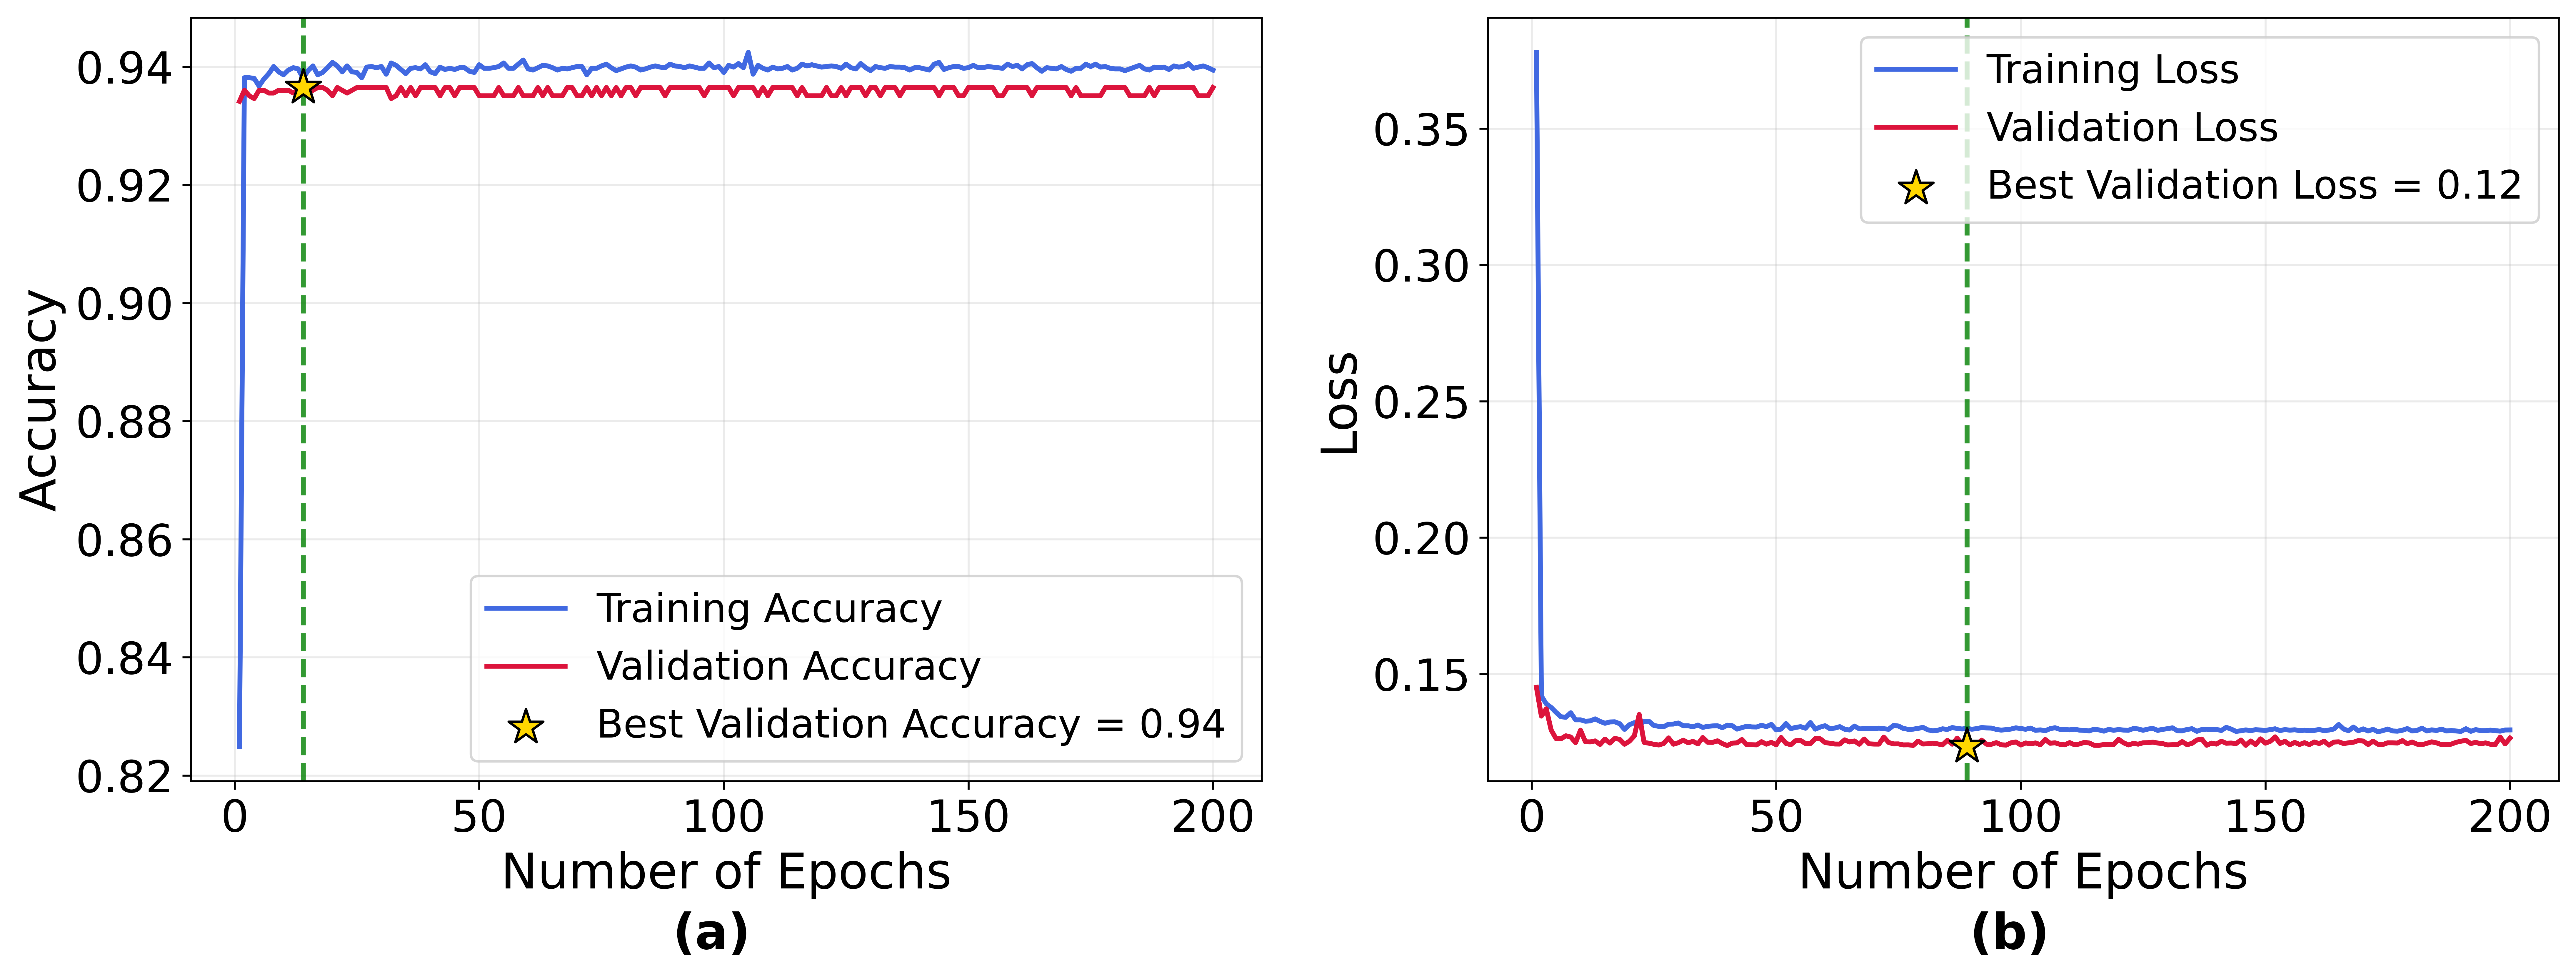

In [25]:
# ============================================================
# Font Settings
# ============================================================
plt.rcParams.update({
    "font.size": 20,
    "axes.titlesize": 20,
    "axes.labelsize": 20,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "legend.fontsize": 16
})

# ============================================================
# Identify Best Epochs
# ============================================================

if "epoch" not in df.columns:
    df["epoch"] = range(1, len(df) + 1)

best_acc_idx = df["val_accuracy"].idxmax()
best_acc_epoch = int(df.loc[best_acc_idx, "epoch"])
best_acc = float(df.loc[best_acc_idx, "val_accuracy"])

best_loss_idx = df["val_loss"].idxmin()
best_loss_epoch = int(df.loc[best_loss_idx, "epoch"])
best_loss = float(df.loc[best_loss_idx, "val_loss"])

# ============================================================
# Combined Learning Curves
# ============================================================

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6), dpi=600)

# ============================================================
# Accuracy Plot
# ============================================================
ax1.plot(df["epoch"], df["accuracy"], linewidth=2,
         color="royalblue", label="Training Accuracy")

ax1.plot(df["epoch"], df["val_accuracy"], linewidth=2,
         color="crimson", label="Validation Accuracy")

ax1.axvline(best_acc_epoch,
            linestyle="--",
            linewidth=2,
            color="green",
            alpha=0.8)

ax1.scatter(best_acc_epoch, best_acc,
            s=220, marker="*", color="gold", edgecolor="black",
            zorder=3,
            label=f"Best Validation Accuracy = {best_acc:.2f}")

ax1.set_xlabel("Number of Epochs")
ax1.set_ylabel("Accuracy")
ax1.grid(True, alpha=0.25)
ax1.legend(frameon=True)

# Accuracy plot ticks
for tick, label in zip(ax1.get_xticks(), ax1.get_xticklabels()):
    if int(tick) == best_acc_epoch:
        label.set_fontweight("bold")
        label.set_color("green")
        
# ============================================================
# Loss Plot
# ============================================================
ax2.plot(df["epoch"], df["loss"], linewidth=2,
         color="royalblue", label="Training Loss")

ax2.plot(df["epoch"], df["val_loss"], linewidth=2,
         color="crimson", label="Validation Loss")

ax2.axvline(best_loss_epoch,
            linestyle="--",
            linewidth=2,
            color="green",
            alpha=0.8)

ax2.scatter(best_loss_epoch, best_loss,
            s=220, marker="*", color="gold", edgecolor="black",
            zorder=3,
            label=f"Best Validation Loss = {best_loss:.2f}")

ax2.set_xlabel("Number of Epochs")
ax2.set_ylabel("Loss")
ax2.grid(True, alpha=0.25)
ax2.legend(frameon=True)

# Loss plot ticks
for tick, label in zip(ax2.get_xticks(), ax2.get_xticklabels()):
    if int(tick) == best_loss_epoch:
        label.set_fontweight("bold")
        label.set_color("green")
        
# ============================================================
# Panel Labels
# ============================================================
ax1.text(0.45, -0.22, "(a)", transform=ax1.transAxes,
         fontsize=20, fontweight="bold")

ax2.text(0.45, -0.22, "(b)", transform=ax2.transAxes,
         fontsize=20, fontweight="bold")

# ============================================================
# Final layout
# ============================================================
fig.tight_layout()

fig.savefig(os.path.join(OUTPUT_DIR, "learning_curves.png"),
            dpi=600, bbox_inches="tight")

fig.savefig(os.path.join(OUTPUT_DIR, "learning_curves.pdf"),
            bbox_inches="tight")

plt.show()

### Classification Report

313/313 [==============================] - 1s 3ms/step

Evaluation Results: Train
Accuracy  : 0.940134
Precision : 0.989739
Recall    : 0.889357
F1-score  : 0.936867
ROC AUC   : 0.985339
----------------------------------------------------------------------
Classification Report:
              precision    recall  f1-score   support

         0.0   0.899746  0.990800  0.943080      5000
         1.0   0.989739  0.889357  0.936867      4989

    accuracy                       0.940134      9989
   macro avg   0.944742  0.940078  0.939973      9989
weighted avg   0.944693  0.940134  0.939977      9989



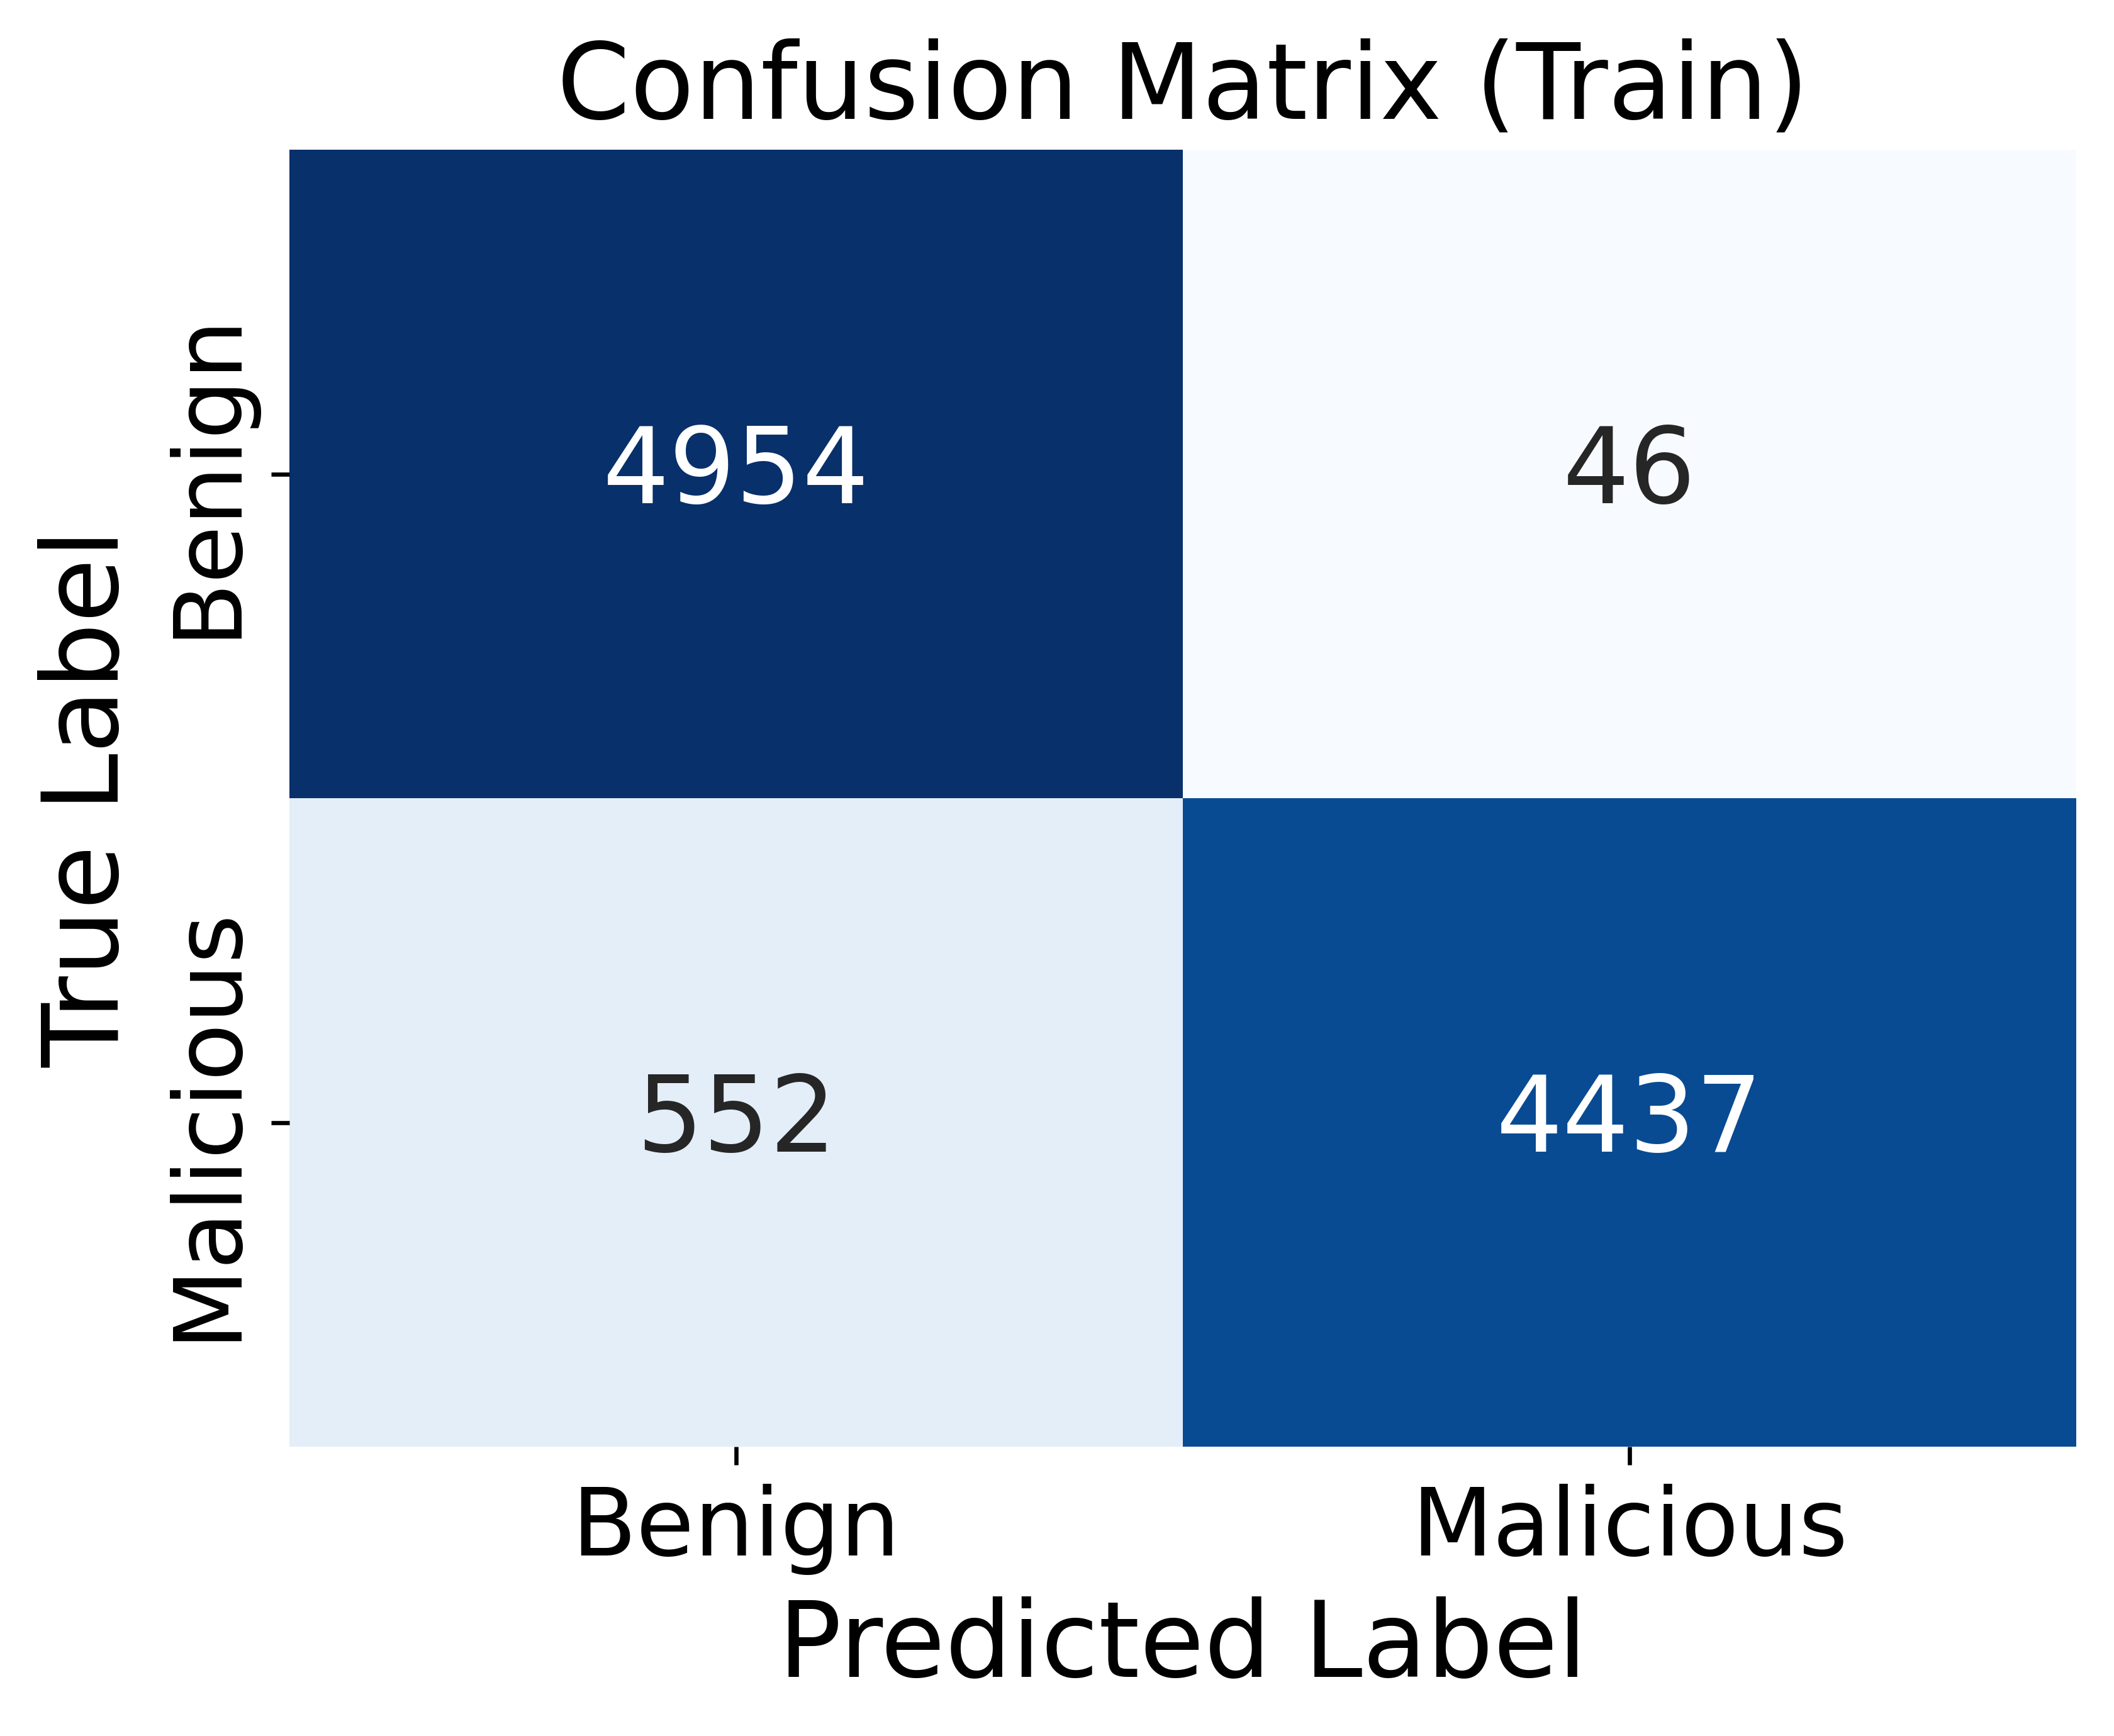

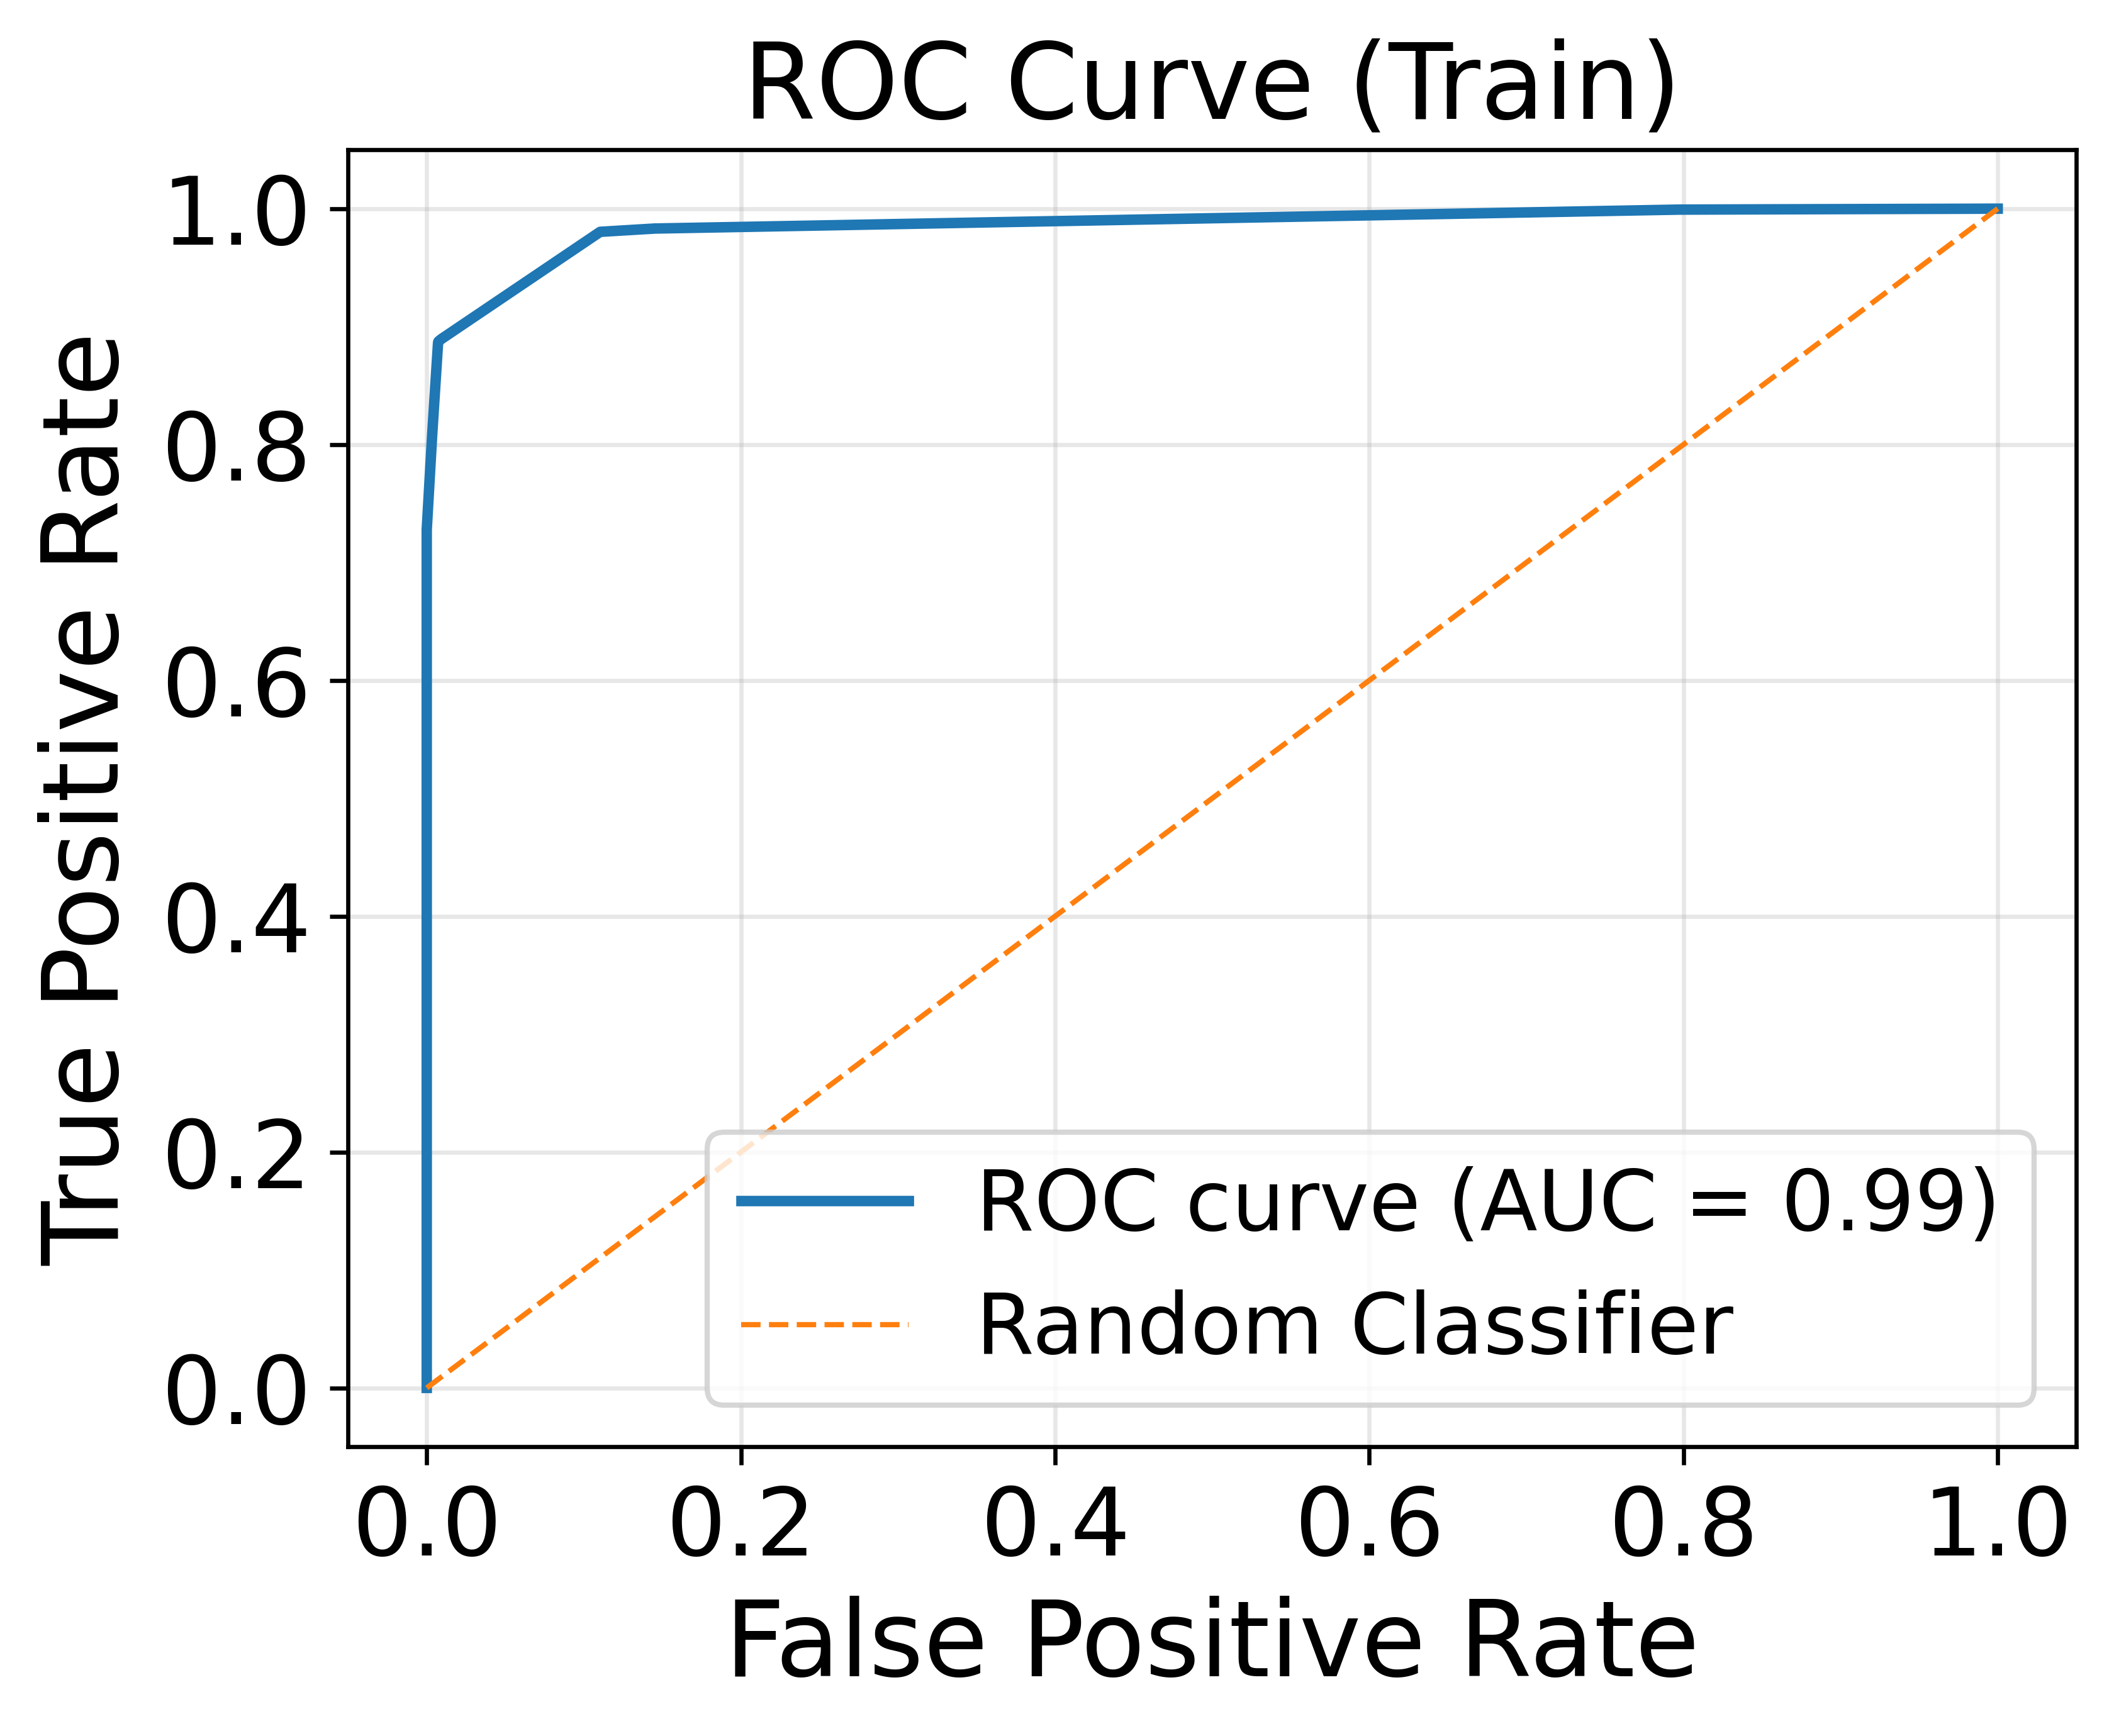

67/67 [==============================] - 0s 2ms/step

Evaluation Results: Validation
Accuracy  : 0.936478
Precision : 0.989507
Recall    : 0.882133
F1-score  : 0.932740
ROC AUC   : 0.987019
----------------------------------------------------------------------
Classification Report:
              precision    recall  f1-score   support

         0.0   0.893939  0.990672  0.939823      1072
         1.0   0.989507  0.882133  0.932740      1069

    accuracy                       0.936478      2141
   macro avg   0.941723  0.936402  0.936281      2141
weighted avg   0.941656  0.936478  0.936286      2141



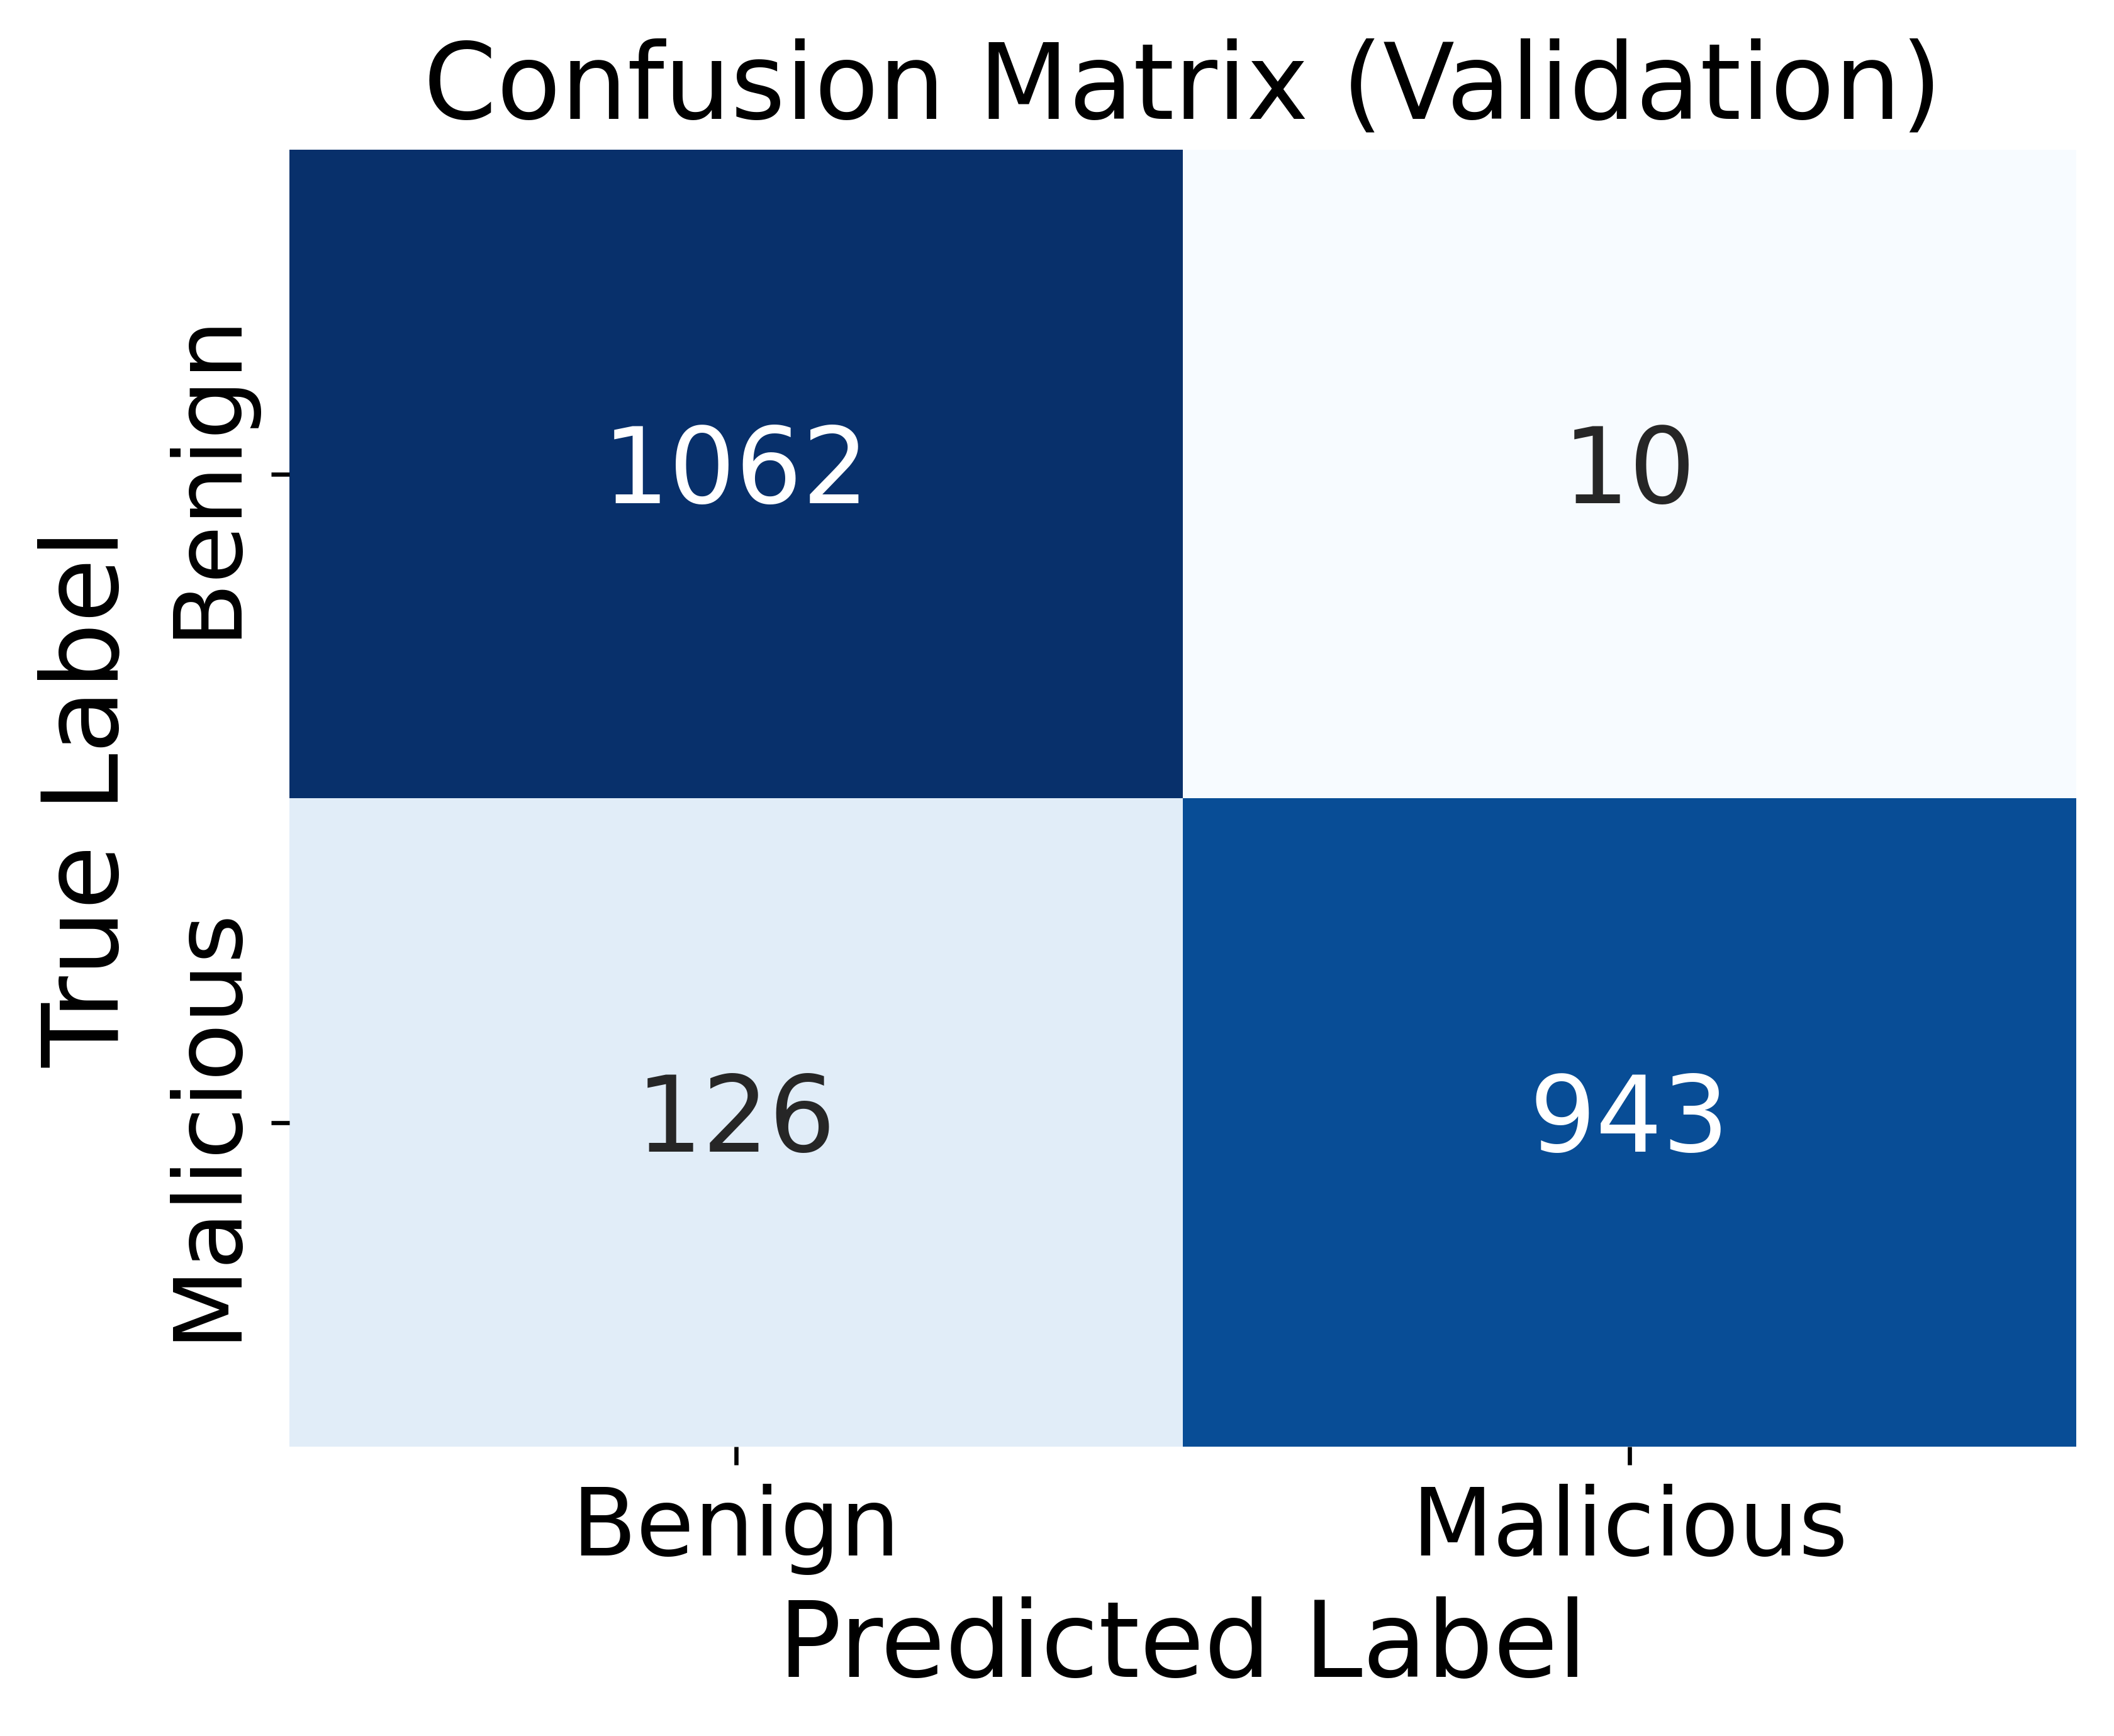

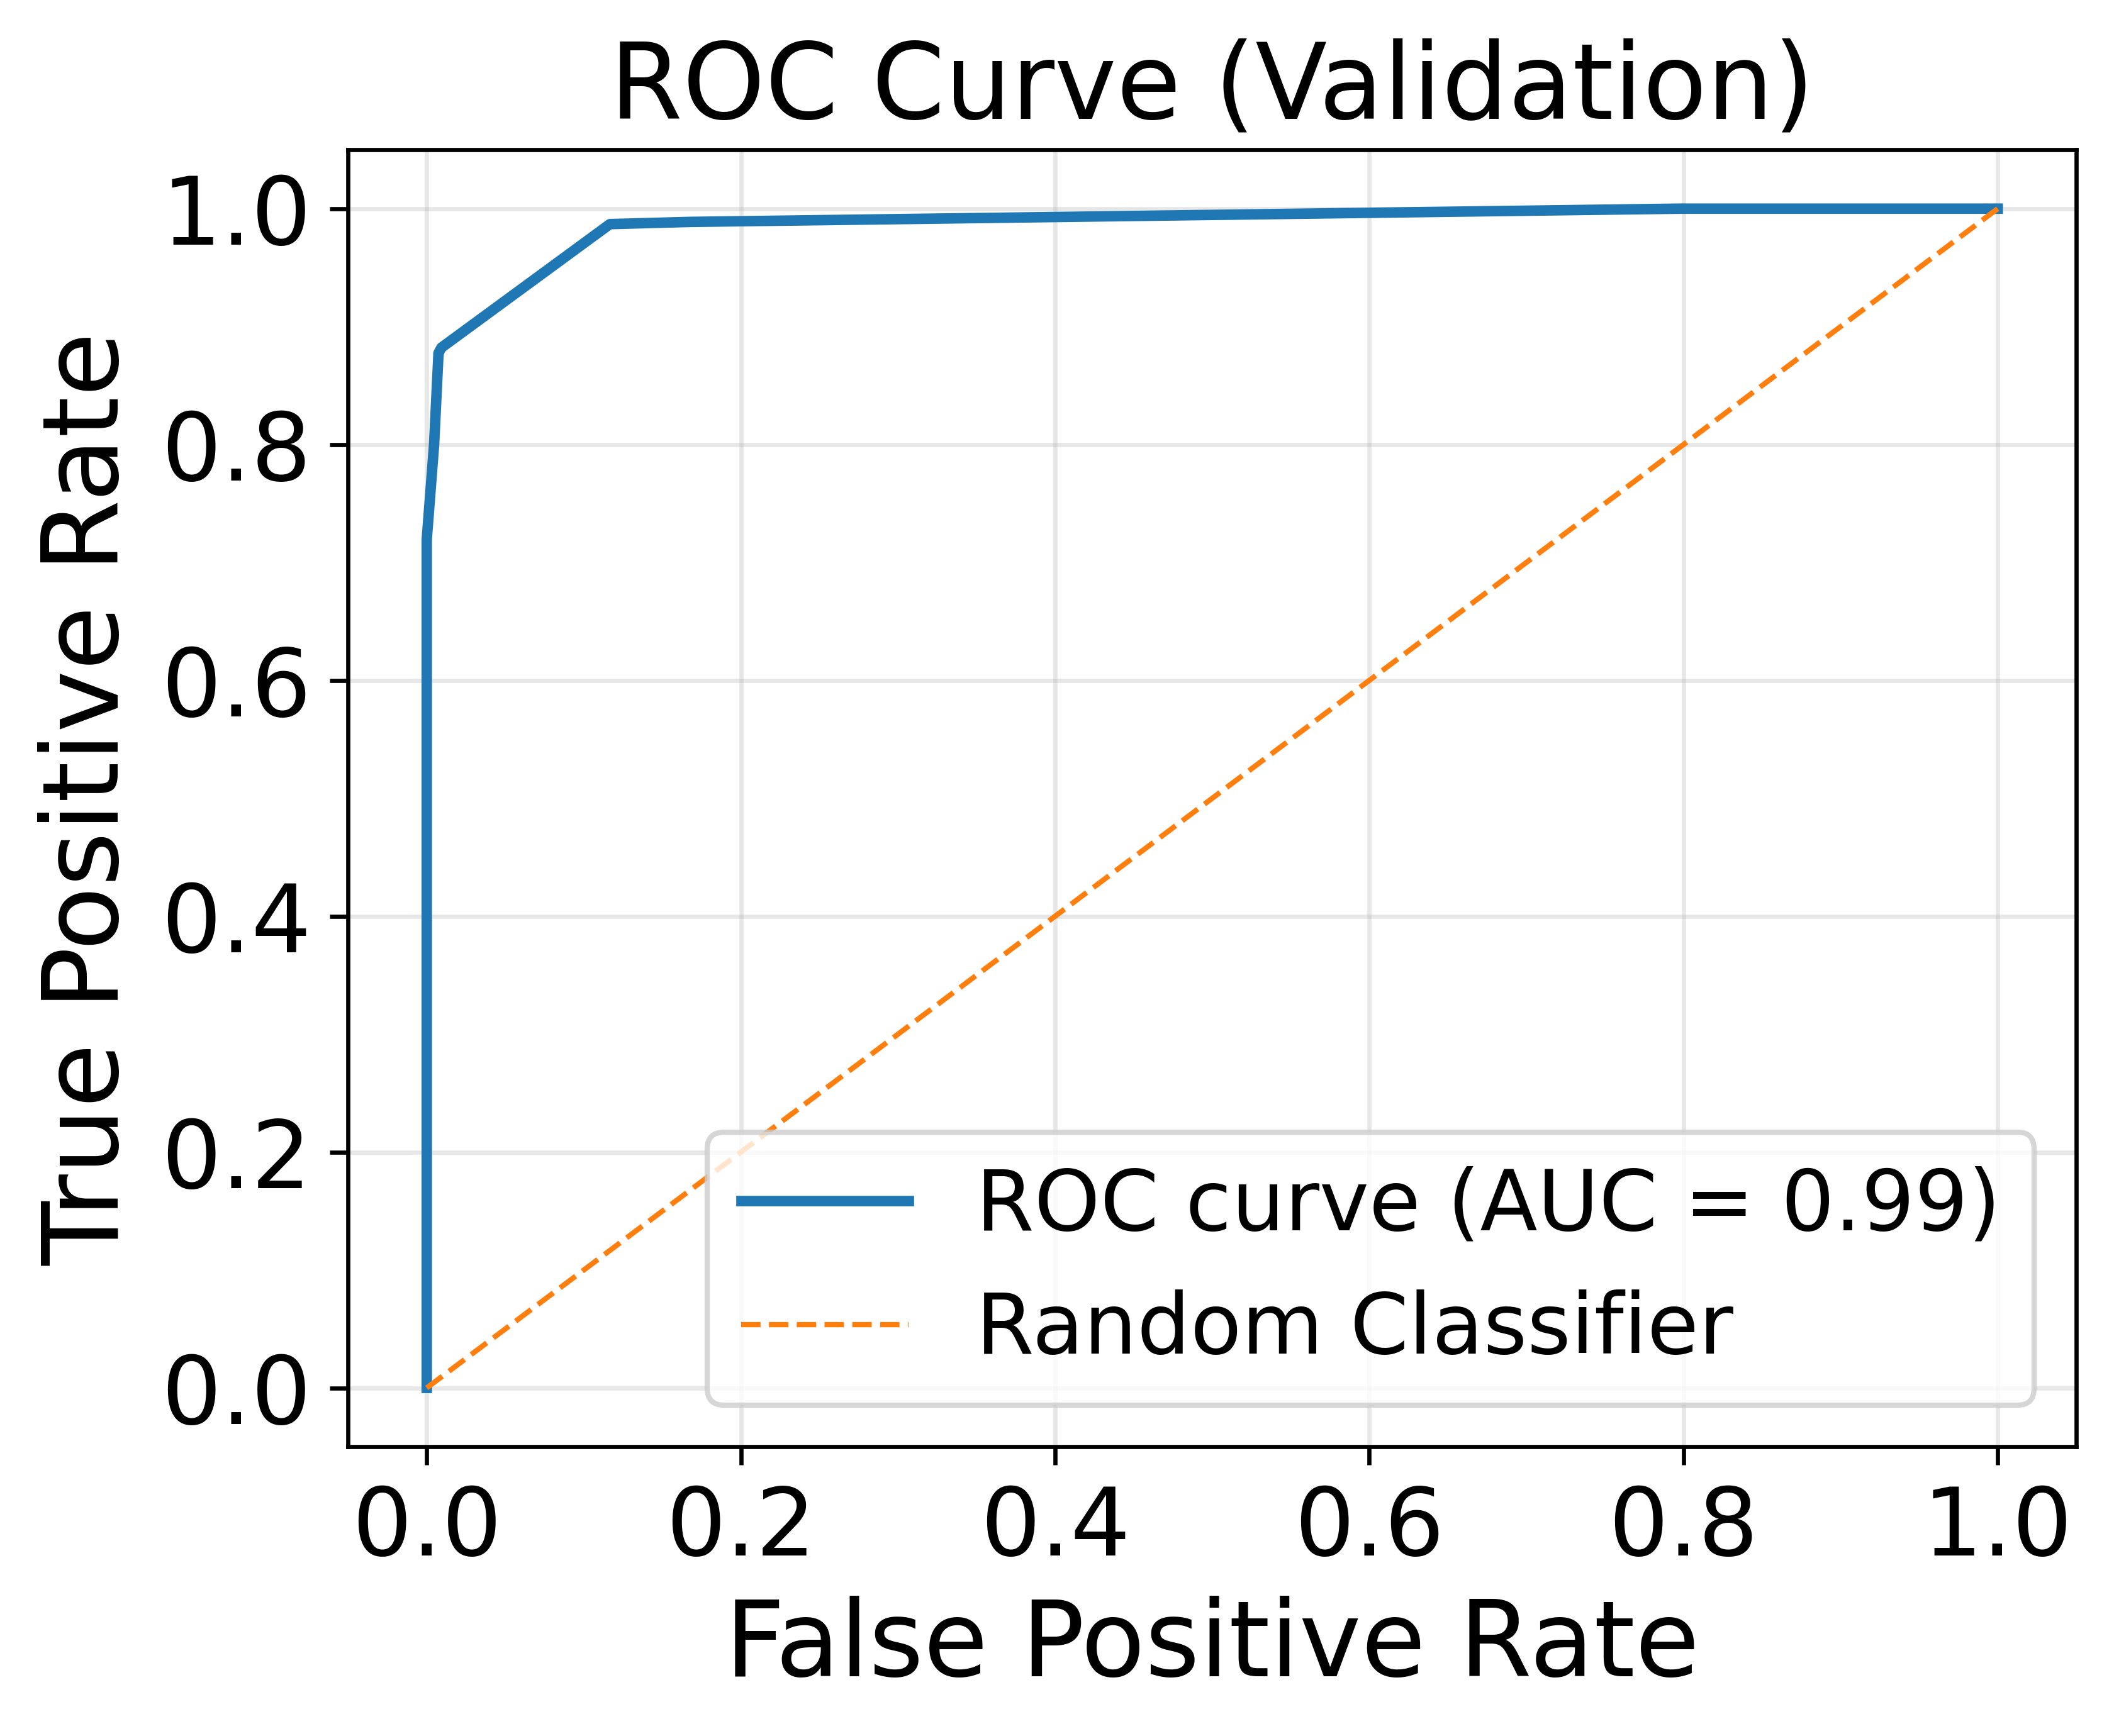

67/67 [==============================] - 0s 5ms/step

Evaluation Results: Test
Accuracy  : 0.941616
Precision : 0.991667
Recall    : 0.890552
F1-score  : 0.938393
ROC AUC   : 0.986808
----------------------------------------------------------------------
Classification Report:
              precision    recall  f1-score   support

         0.0   0.900931  0.992537  0.944518      1072
         1.0   0.991667  0.890552  0.938393      1069

    accuracy                       0.941616      2141
   macro avg   0.946299  0.941545  0.941456      2141
weighted avg   0.946235  0.941616  0.941460      2141



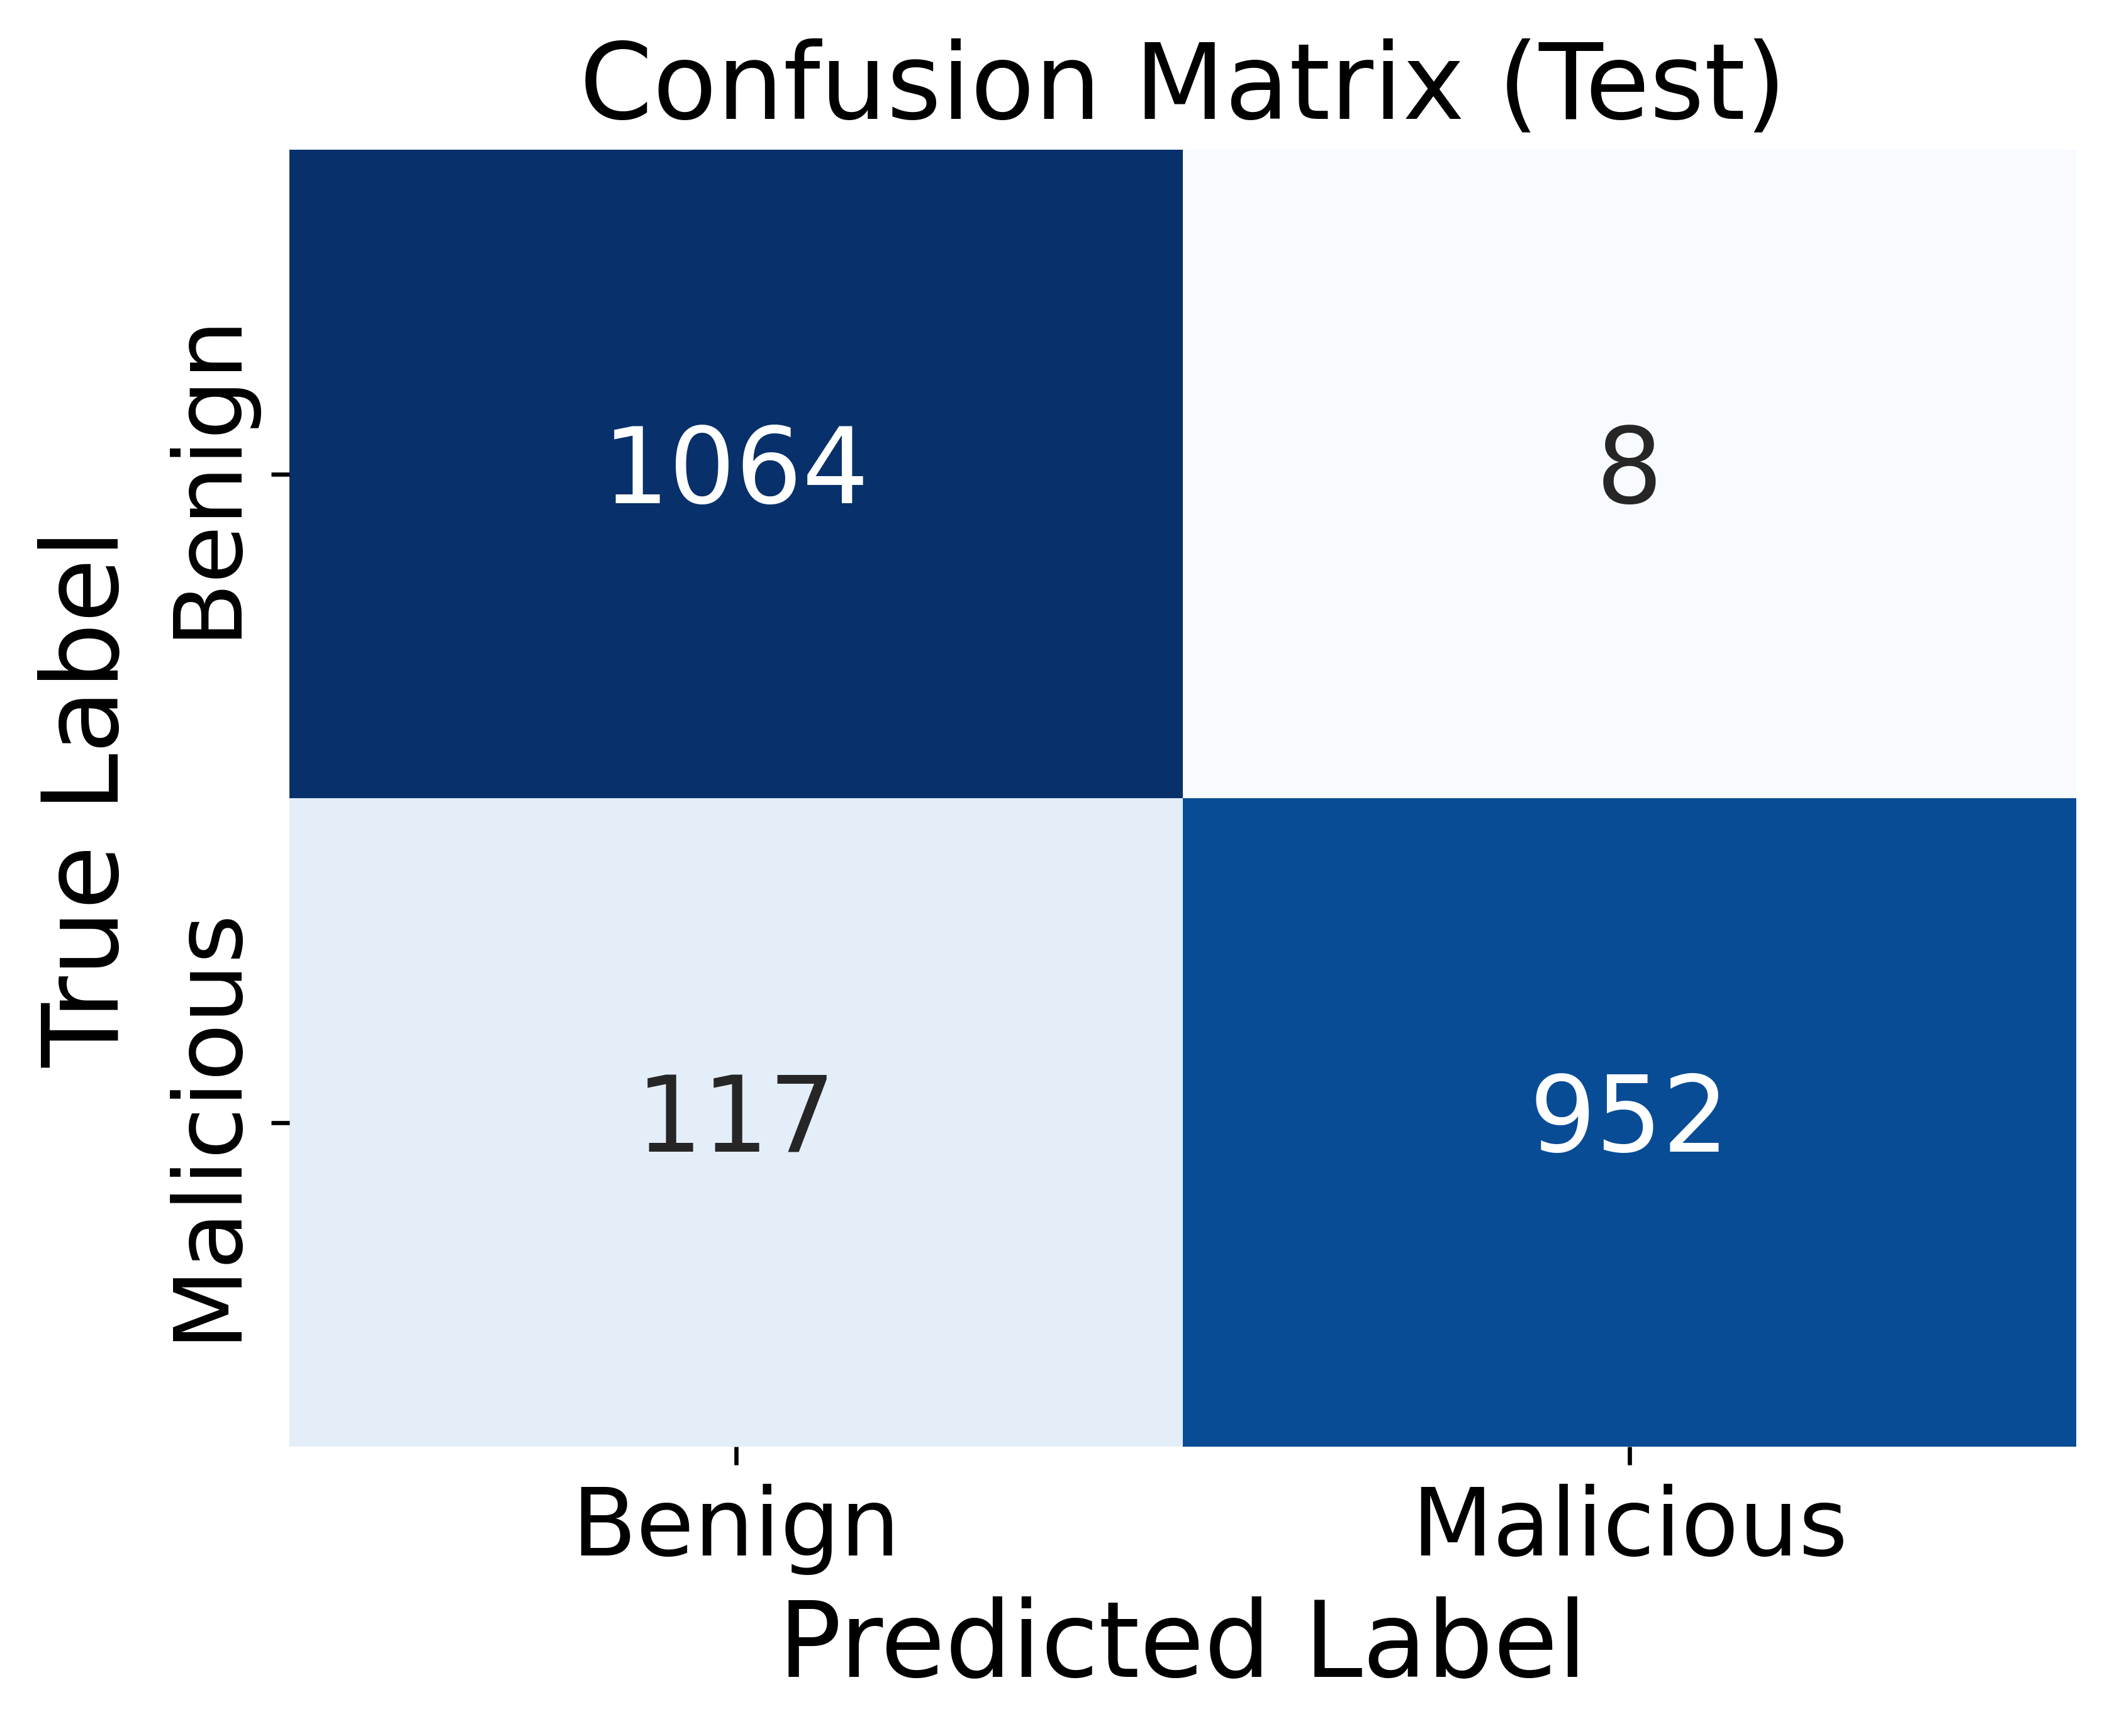

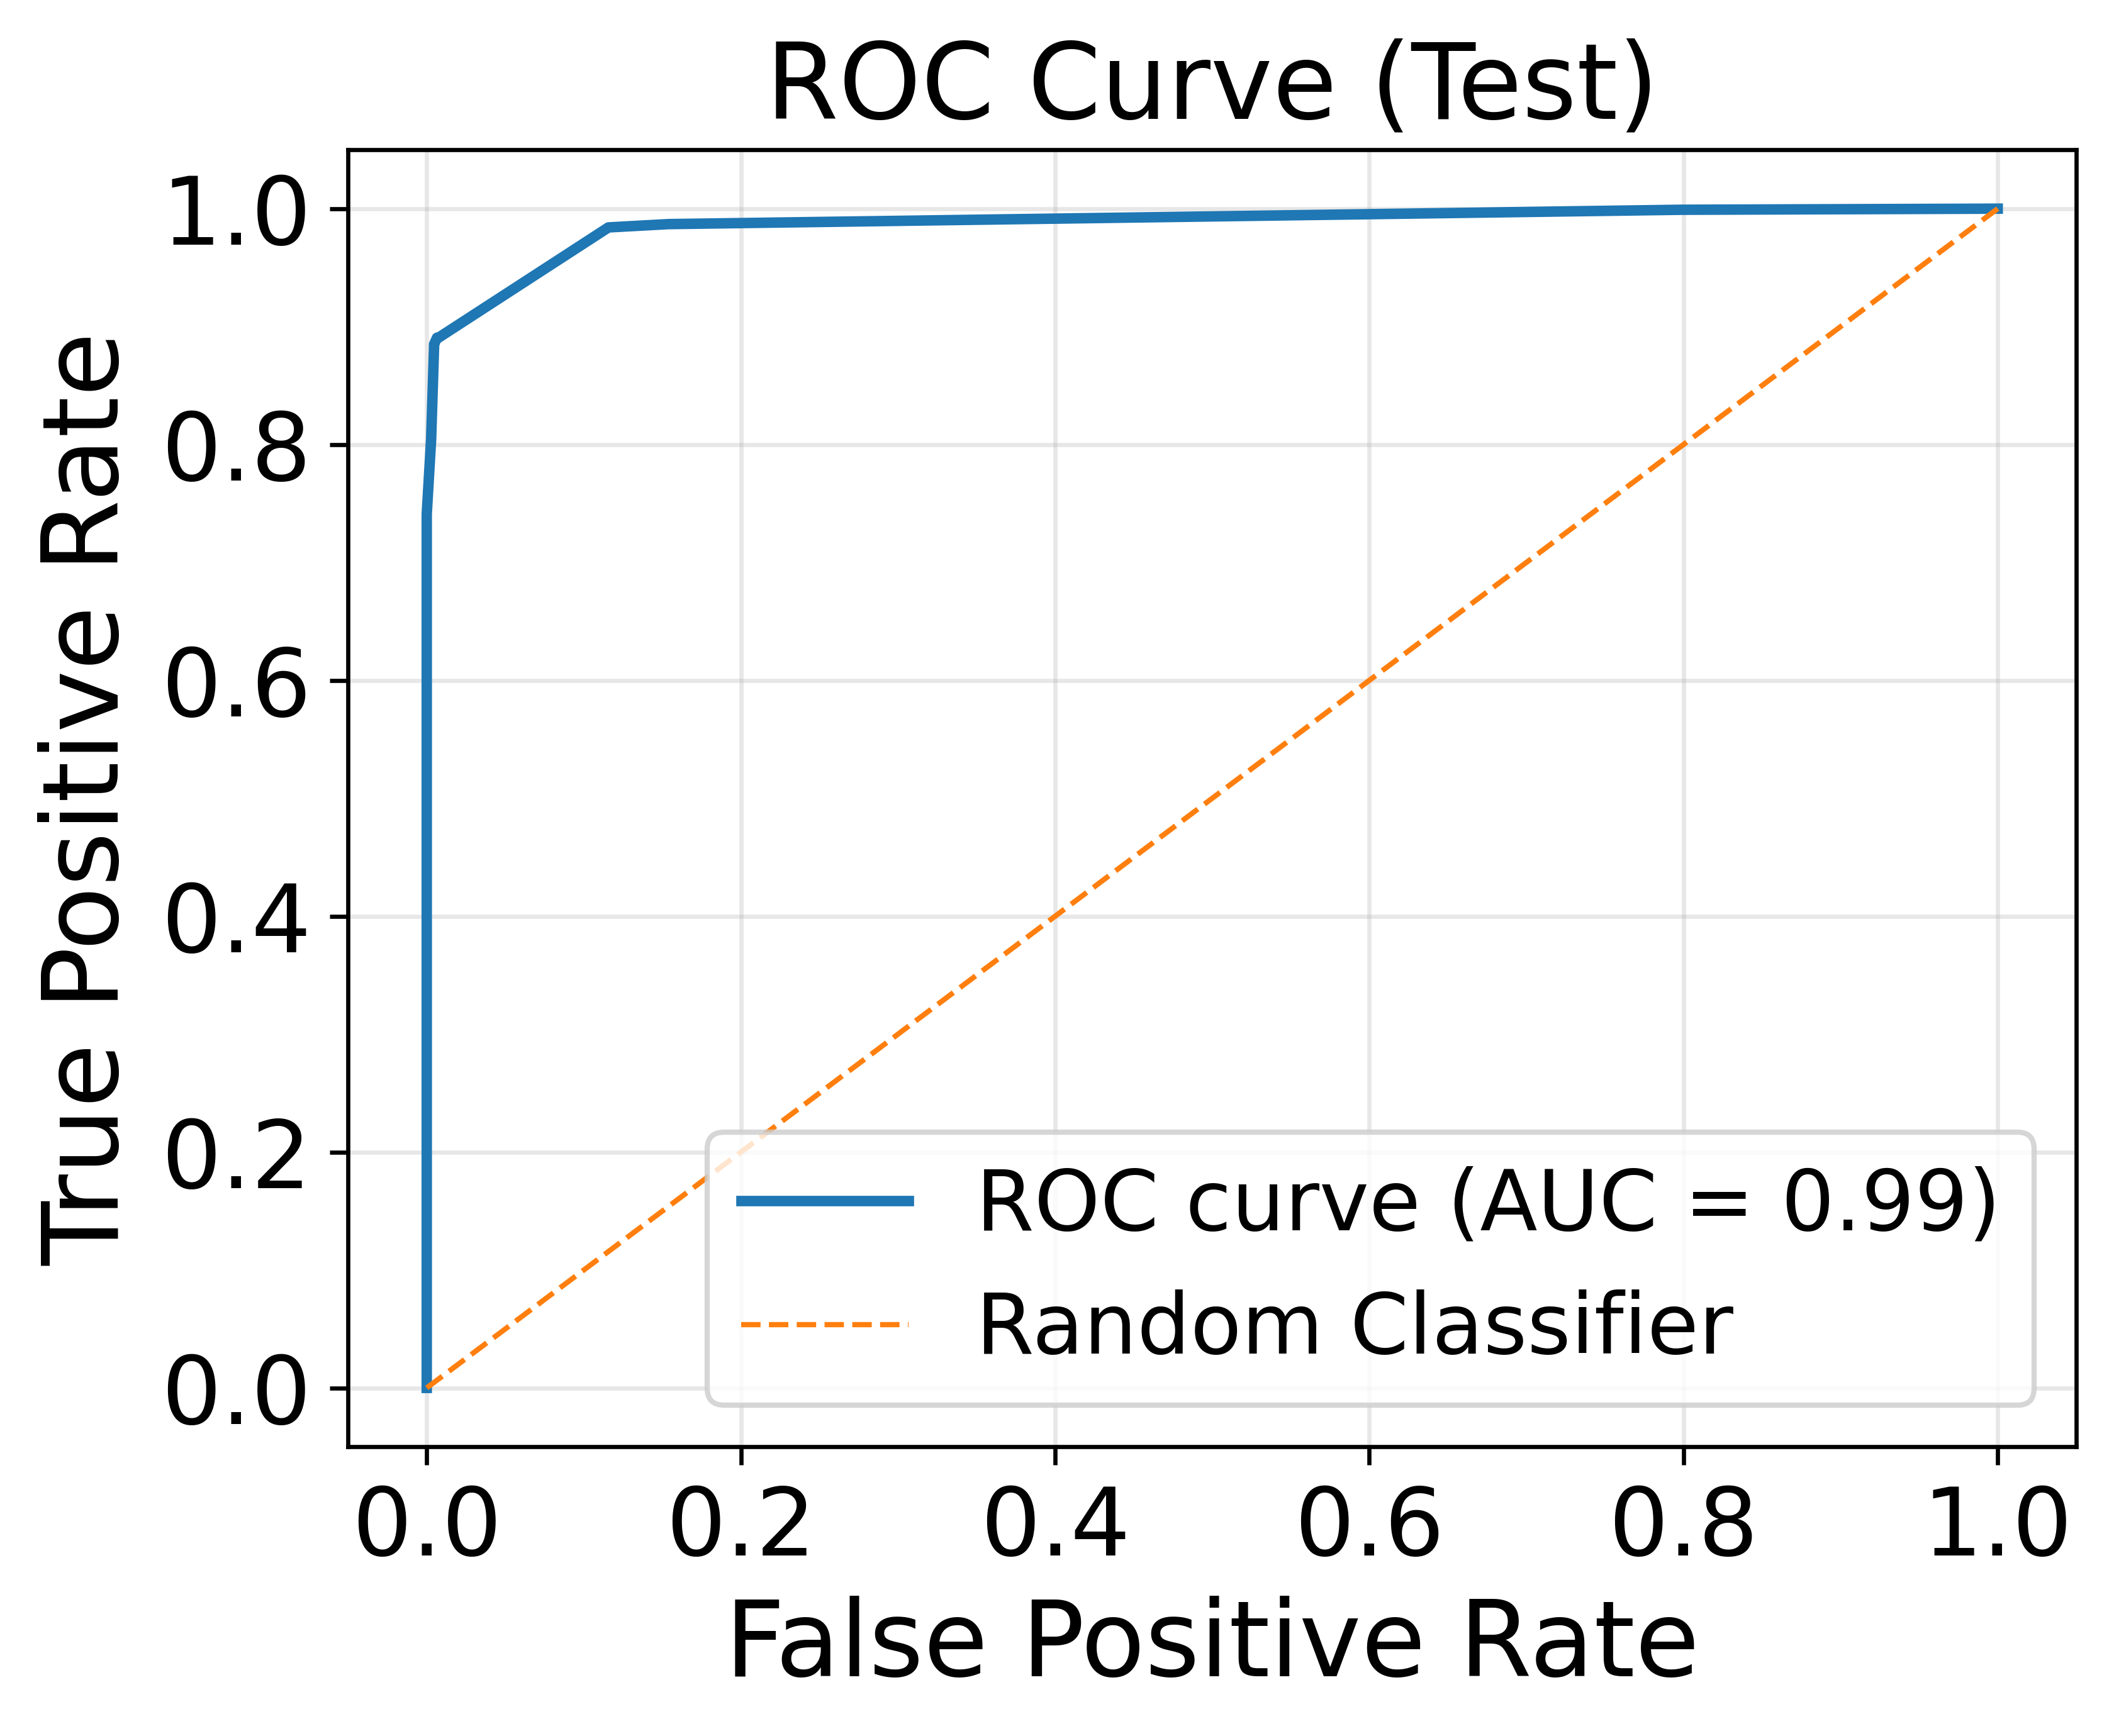

In [26]:
def evaluate_and_plot(model, X, y_true, dataset_name, output_dir=OUTPUT_DIR):
    """
    Evaluate the trained model on a given dataset and generate
    publication-quality confusion matrix and ROC curve figures.

    Parameters
    ----------
    model : keras.Model
        Trained classification model.
    encodings : dict or BatchEncoding
        Tokenized transformer inputs containing 'input_ids' and 'attention_mask'.
    y_true : array-like
        Ground-truth labels.
    dataset_name : str
        Name of the dataset split (e.g., 'Train', 'Validation', 'Test').
    output_dir : str, optional
        Directory where evaluation figures will be saved.

    Returns
    -------
    results : dict
        Dictionary containing predictions and evaluation metrics.
    """

    # --------------------------------------------------------
    # Generate predictions
    # --------------------------------------------------------
    y_prob = model.predict(X).ravel()
    y_pred = (y_prob > 0.5).astype("int32")

    # --------------------------------------------------------
    # Compute evaluation metrics
    # --------------------------------------------------------
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)

    cm = confusion_matrix(y_true, y_pred)
    report = classification_report(y_true, y_pred, digits=6)

    # --------------------------------------------------------
    # Print evaluation summary
    # --------------------------------------------------------
    print("\n" + "=" * 70)
    print(f"Evaluation Results: {dataset_name}")
    print("=" * 70)
    print(f"Accuracy  : {acc:.6f}")
    print(f"Precision : {prec:.6f}")
    print(f"Recall    : {rec:.6f}")
    print(f"F1-score  : {f1:.6f}")
    print(f"ROC AUC   : {roc_auc:.6f}")
    print("-" * 70)
    print("Classification Report:")
    print(report)

    # --------------------------------------------------------
    # Plot and save confusion matrix
    # --------------------------------------------------------
    plt.figure(figsize=(6, 5), dpi=600)
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        xticklabels=["Benign", "Malicious"],
        yticklabels=["Benign", "Malicious"]
    )
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(f"Confusion Matrix ({dataset_name})")
    plt.tight_layout()

    cm_png = os.path.join(output_dir, f"confusion_matrix_{dataset_name.lower()}.png")
    cm_pdf = os.path.join(output_dir, f"confusion_matrix_{dataset_name.lower()}.pdf")
    plt.savefig(cm_png, dpi=600, bbox_inches="tight")
    plt.savefig(cm_pdf, bbox_inches="tight")
    plt.show()

    # --------------------------------------------------------
    # Plot and save ROC curve
    # --------------------------------------------------------
    plt.figure(figsize=(6, 5), dpi=600)
    plt.plot(fpr, tpr, linewidth=2, label=f"ROC curve (AUC = {roc_auc:.2f})")
    plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1, label="Random Classifier")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve ({dataset_name})")
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.tight_layout()

    roc_png = os.path.join(output_dir, f"roc_curve_{dataset_name.lower()}.png")
    roc_pdf = os.path.join(output_dir, f"roc_curve_{dataset_name.lower()}.pdf")
    plt.savefig(roc_png, dpi=600, bbox_inches="tight")
    plt.savefig(roc_pdf, bbox_inches="tight")
    plt.show()

    # --------------------------------------------------------
    # Return results for further analysis/reporting
    # --------------------------------------------------------
    results = {
        "dataset": dataset_name,
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1_score": f1,
        "roc_auc": roc_auc,
        "confusion_matrix": cm,
        "classification_report": report,
        "y_true": np.array(y_true),
        "y_pred": y_pred,
        "y_prob": y_prob,
        "confusion_matrix_png": cm_png,
        "confusion_matrix_pdf": cm_pdf,
        "roc_curve_png": roc_png,
        "roc_curve_pdf": roc_pdf
    }

    return results


# ============================================================
# Evaluate on Training, Validation, and Test Sets
# ============================================================

train_results = evaluate_and_plot(model, X_train_pad, y_train, "Train")
val_results   = evaluate_and_plot(model, X_val_pad, y_val, "Validation")
test_results  = evaluate_and_plot(model, X_test_pad, y_test, "Test")

### Save All Results

In [27]:
# ------------------------------------------------------------
# Create summary DataFrame
# ------------------------------------------------------------
summary_df = pd.DataFrame([
    {
        "Dataset": train_results["dataset"],
        "Accuracy": train_results["accuracy"],
        "Precision": train_results["precision"],
        "Recall": train_results["recall"],
        "F1-score": train_results["f1_score"],
        "ROC AUC": train_results["roc_auc"]
    },
    {
        "Dataset": val_results["dataset"],
        "Accuracy": val_results["accuracy"],
        "Precision": val_results["precision"],
        "Recall": val_results["recall"],
        "F1-score": val_results["f1_score"],
        "ROC AUC": val_results["roc_auc"]
    },
    {
        "Dataset": test_results["dataset"],
        "Accuracy": test_results["accuracy"],
        "Precision": test_results["precision"],
        "Recall": test_results["recall"],
        "F1-score": test_results["f1_score"],
        "ROC AUC": test_results["roc_auc"]
    }
])

# ------------------------------------------------------------
# Define save paths
# ------------------------------------------------------------
csv_path  = os.path.join(OUTPUT_DIR, "evaluation_summary.csv")
xlsx_path = os.path.join(OUTPUT_DIR, "evaluation_summary.xlsx")

# ------------------------------------------------------------
# Save files
# ------------------------------------------------------------
summary_df.to_csv(csv_path, index=False)
summary_df.to_excel(xlsx_path, index=False)

# ------------------------------------------------------------
# Confirmation
# ------------------------------------------------------------
print("=" * 60)
print("Evaluation summary saved successfully:")
print(f"CSV  : {csv_path}")
print(f"Excel: {xlsx_path}")
print("=" * 60)

# Display table
summary_df

Evaluation summary saved successfully:
CSV  : Evaluation_Outputs_SysCall_FLAML_Pre_Attention_LSTM/evaluation_summary.csv
Excel: Evaluation_Outputs_SysCall_FLAML_Pre_Attention_LSTM/evaluation_summary.xlsx


,Dataset,Accuracy,Precision,Recall,F1-score,ROC AUC
0,Train,0.940134,0.989739,0.889357,0.936867,0.985339
1,Validation,0.936478,0.989507,0.882133,0.932740,0.987019
2,Test,0.941616,0.991667,0.890552,0.938393,0.986808


### Clear Final Backend Session

In [28]:
# ============================================================
# Memory Management and Session Reset
# ============================================================

# Trigger garbage collection to free unused memory
gc.collect()

# Clear the current TensorFlow/Keras session to release GPU/CPU resources
# This is particularly important when training multiple models sequentially
tf.keras.backend.clear_session()